In [28]:
#Importing stuff I will need 

import os
import numpy as np
import distutils    
from srim import Ion, Layer, Target, TRIM #needs to go to elementdb.py and change line 1
from srim.output import Results
import matplotlib.pyplot as plt
from itertools import count
from pathlib import Path
from collections import Counter
from random import randint
import math
import scipy.integrate as integrate
import shutil
import pandas as pd
from matplotlib import rcParams
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.integrate import cumulative_trapezoid
from datetime import datetime
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter
from matplotlib.cm import ScalarMappable
from charset_normalizer import detect




In [29]:
# General font properties 

legend_font_properties = {'family': 'Times New Roman', 'size': 16}
font_properties = {'family': 'Times New Roman', 'size': 16}

In [ ]:
# For all code blocks below, please edit the file path, file names and folders as necessary. The variable names assigned right now correspond to 
# folder and file name on my local disk

In the section below, a sample SAW signal is plotted for gold and for tungsten coatings on CVD 3C-SiC

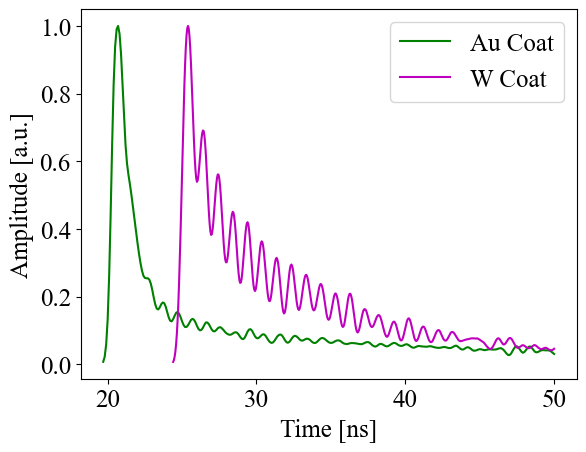

Text(0, 0.5, 'Amplitude [mV]')

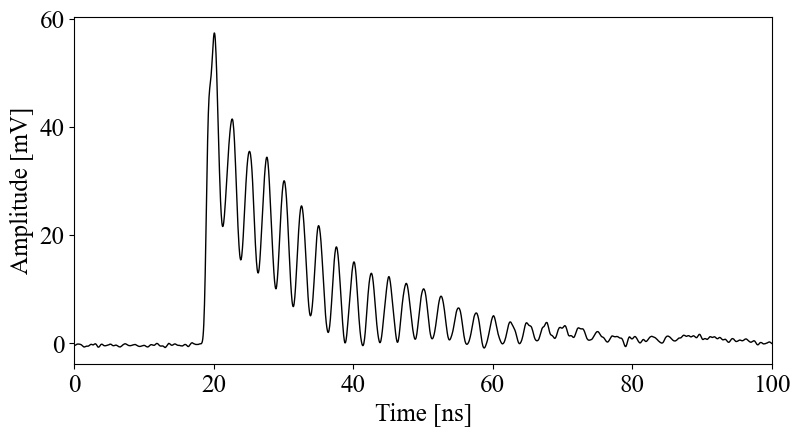

In [30]:
file_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\PremaTech_CVD_SiC_2\\2024-11-14-Tru2\\"
file_name_pos_1_hour = "PremaTech_CVD_SiC_2-2024-11-14-Tru2-06.40um-spot03-POS-70.txt"
file_name_pos_pre = "PremaTech_CVD_SiC_2-2024-11-14-Tru2-06.40um-spot03-POS-10.txt"

data_1_hour = np.loadtxt(file_path + file_name_pos_1_hour, skiprows=17)
data_pre = np.loadtxt(file_path + file_name_pos_pre, skiprows=17)

time_100ns = np.where(data_pre[:, 0] >= 50*1e-9)[0][0]
time_max = np.where(data_pre[:, 1] == np.max(data_pre[:, 1]))[0][0] - 10

#print(time_100ns, time_max, len(data_pre[time_max:, 0]))

rcParams['font.family'] = 'Times New Roman'

#plt.plot(1e9*data_1_hour[100:500, 0], 1e3*data_1_hour[100:500, 1], color='b', label='After 1 hour of Irradiation')
plt.plot(1e9*data_pre[time_max:time_100ns, 0], 1e3*data_pre[time_max:time_100ns, 1]/np.max(1e3*data_pre[time_max:time_100ns, 1]), color='g', linestyle = '-')#, label='Before Irradiation')
plt.xlabel('Time [ns]', fontsize=18, fontname='Times New Roman')
plt.ylabel('Amplitude [a.u.]', fontsize=18, fontname='Times New Roman')
#plt.title("After 1 hour of Irradiation", fontsize=12)

plt.tick_params(axis='both', which='major', labelsize=18) 

file_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\PremaTech_CVD_SiC_Heating_Wcoat\\2025-05-14\\"
file_name_pos_1_hour = "PremaTech_CVD_SiC_2-2024-11-14-Tru2-06.40um-spot03-POS-70.txt"
file_name_pos_pre = "PremaTech_CVD_SiC_Heating_Wcoat-2025-05-14-06.40um-Heating_trial_RT-POS-1.txt"

#data_1_hour = np.loadtxt(file_path + file_name_pos_1_hour, skiprows=17)
data_pre = np.loadtxt(file_path + file_name_pos_pre, skiprows=17)

time_100ns = np.where(data_pre[:, 0] >= 50*1e-9)[0][0]
time_max = np.where(data_pre[:, 1] == np.max(data_pre[:, 1]))[0][0] - 20

rcParams['font.family'] = 'Times New Roman'

#plt.plot(1e9*data_1_hour[100:500, 0], 1e3*data_1_hour[100:500, 1], color='b', label='After 1 hour of Irradiation')
plt.plot(1e9*data_pre[time_max:time_100ns, 0], 1e3*data_pre[time_max:time_100ns, 1]/np.max(1e3*data_pre[time_max:time_100ns, 1]), color='m', linestyle = '-', label='Before Irradiation')
plt.legend(('Au Coat', 'W Coat'), fontsize=18)
plt.show()
#plt.legend(('Au Coat'), fontsize=18)

w_file_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\PremaTech_CVD_SiC_HeandSi\\Tungsten_Calibration_2025-11-01\\"
w_pos_filename = "Tungsten_Calibration-2025-11-01-06.40um-spot01-POS-1.txt"
data_pre = np.loadtxt(w_file_path + w_pos_filename, skiprows=17)


plt.subplots(figsize=(9, 4.5))

fig = plt.plot(1e9*data_pre[:, 0], 1000*data_pre[:, 1], linewidth = 1, color='k')
plt.xlim([0, 100])
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Time [ns]', fontsize=18)
plt.ylabel('Amplitude [mV]', fontsize = 18) 





Plotting thermal diffusivity and SAW speed as a function of temperature as measured using TGS

126.246 90.22976840625 0.7147138793011264


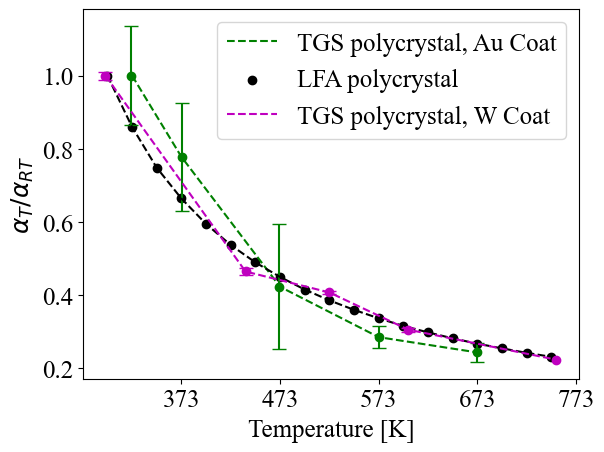

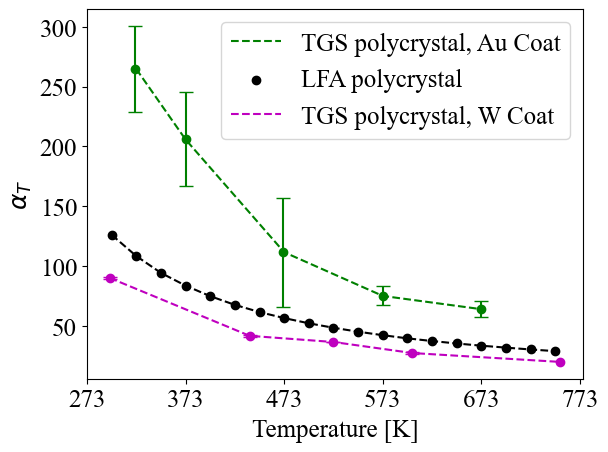

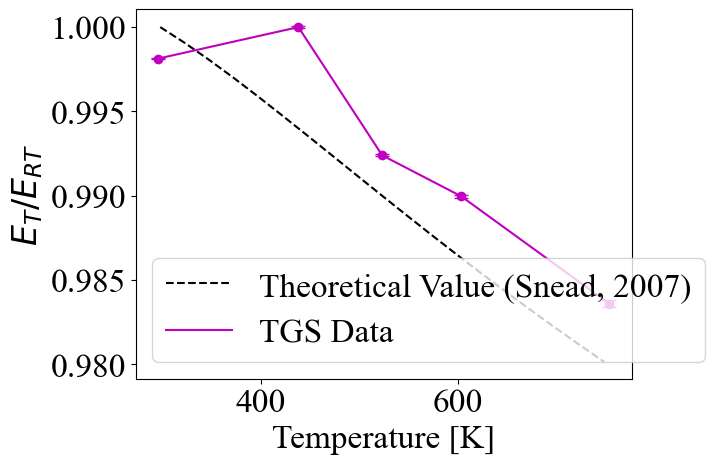

109.65434944473489
-28.52861206988736


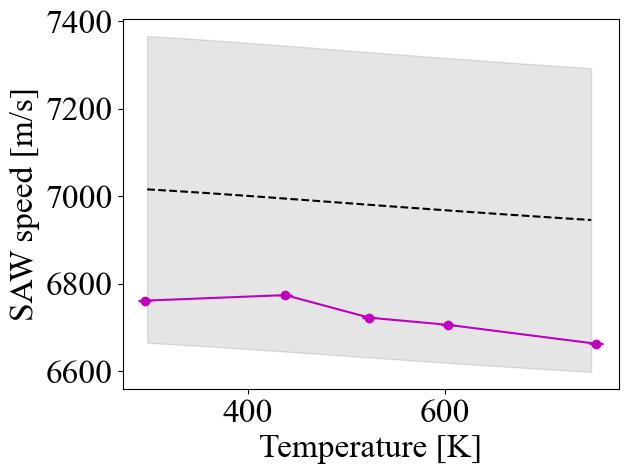

In [31]:
#Postprocessing for heating trial

file_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\PremaTech_CVD_SiC_1_Heating\\2024-12-17\\"
file_name = "PremaTech_CVD_SiC_1_Heating-2024-12-17-06.40um-spot04_postprocessing.txt"

temperature = []
run = []
diff = []
diff_err = []
with open(file_path+file_name, 'r') as file:
    for line in file:
        if "temperature[C] Run_number alpha[m^2s^-1] alpha_err[m2s-1]" not in line:
            parts = line.split()
            temperature.append(float(parts[0]))
            diff.append(float(parts[2])*1e6) #converting to float and to mm^2/s
            diff_err.append(float(parts[3])*1e6) #converting to float and to mm^2/s


runs = 12
nominal_temperature = [50, 100, 200, 300, 400]
j = 0
diff_final = [] #single_diff value for every temperature
diff_std = []
for i in range(len(nominal_temperature)):
    temp_diff = []
    for j in np.arange(12):
        index = 12*i + j
        #print(index)
        if diff_err[index] < 100:
            temp_diff.append(diff[index])
            #print(diff[index])
    diff_final.append(np.mean(temp_diff))
    diff_std.append(np.std(temp_diff))

measured_temp_index = [11036, 11706, 18956, 19915, 21716, 22496, 23636, 24415, 25376, 26156]
measured_temp_filename = '20241217_PremaTech_CVD_SiC_1_Heating.csv'
with open(file_path + measured_temp_filename, 'rb') as f:
    result = detect(f.read())
measured_temp_data = pd.read_csv(file_path + measured_temp_filename, encoding=result['encoding'])
measured_temp_data.columns = ['Random', 'Measured Temp']

measured_temp_mean = []
measured_temp_std = []

for i in range(len(nominal_temperature)):
    index = i*2
    selected_measured_temp_data = measured_temp_data[measured_temp_index[index]:measured_temp_index[index + 1]]
    selected_measured_temp_data = selected_measured_temp_data['Measured Temp'].to_numpy()
    selected_measured_temp_data = selected_measured_temp_data.astype(float)
    measured_temp_mean.append(np.mean(selected_measured_temp_data))
    measured_temp_std.append(np.std(selected_measured_temp_data))

LFA_filename = 'PremaTech_CVD_SiC_5_LFA.csv'
with open(file_path + LFA_filename, 'rb') as f:
    result = detect(f.read())
data = pd.read_csv(file_path + LFA_filename, encoding=result['encoding'])
starting_row = 31
row_interval = 5
temp_column = 2
diff_column = 4
selected_rows = data.iloc[starting_row::row_interval]
selected_data = selected_rows.iloc[:, [temp_column, diff_column]]

selected_data.rename(columns={'Unnamed: 2': 'new_col1', 'Unnamed: 4': 'new_col2'})
selected_data.columns = ['Temperature', 'Diffusivity']

LFA_temp = selected_data['Temperature'].to_numpy()
LFA_temp = LFA_temp.astype(int)
LFA_diff = selected_data['Diffusivity'].to_numpy()
LFA_diff = LFA_diff.astype(float)

#Data for Single Crystal SiC taken from Thermo-mechanical properties of silicon, germanium, diamond, beryllium and silicon carbide for high heat load x-ray optics applications
T_SiC_single_xtal = np.array([300.59, 502.69, 779.85, 994.04, 1195.92]) #in K
k_SiC_single_xtal = np.array([496.74, 246.75, 132.30, 113.56, 91.47]) # in W/m/K
#heat_capacity_sic = 20.5009 + 63.3717*T_SiC_single_xtal*0.001 -49.54023*(T_SiC_single_xtal*0.001)**2 + 14.82801*(T_SiC_single_xtal*0.001)**3 - 0.759969/((T_SiC_single_xtal*0.001)**2) #cp in J/mol/K from NIST
specific_heat_SiC = 1e-3*(925.65 + 0.3722*T_SiC_single_xtal - 7.9259*1e-5*(T_SiC_single_xtal**2) -3.1946*1e7/(T_SiC_single_xtal**2)) #from snead et al (Handbook of SiC properties), in J/g/K
density = 3.21 #in g/cm^3 - assumed to be constant over temperature
diff_SiC_single_xtal = k_SiC_single_xtal/density/specific_heat_SiC


index = np.where(LFA_temp == 500)[0][0]


#plt.errorbar(nominal_temperature, diff_final, diff_std, fmt='o', color='black', ecolor='black', capsize=5)
#plt.plot(nominal_temperature, diff_final, linestyle='--', color='k', label='TGS')

rcParams['font.family'] = 'Times New Roman'

plt.errorbar(np.array(measured_temp_mean) + 273, diff_final/diff_final[0], yerr=diff_std/diff_final[0], fmt='o', color='g', ecolor='g', capsize=5)
plt.plot(np.array(nominal_temperature) + 273, diff_final/diff_final[0], linestyle='--', color='g', label='TGS polycrystal, Au Coat')
plt.scatter(np.array(LFA_temp[0:index]) + 273,LFA_diff[0:index]/LFA_diff[0], color = 'k', label='LFA polycrystal')
plt.plot(np.array(LFA_temp[0:index]) + 273,LFA_diff[0:index]/LFA_diff[0], linestyle='--', color = 'k')
#plt.plot(LFA_temp[0:index],2*np.array(LFA_diff[0:index]), linestyle=':', color = 'b', label='LFA 2x')
#plt.scatter(T_SiC_single_xtal[0:3]-273, diff_SiC_single_xtal[0:3]/diff_SiC_single_xtal[0], color = 'm')
#plt.plot(T_SiC_single_xtal[0:3]-273, diff_SiC_single_xtal[0:3]/diff_SiC_single_xtal[0], linestyle = '--', color = 'm', label='LFA single crystal [1]')
#plt.ylabel("Thermal Diffusivity [mm^2/s]", fontsize=18, fontname = 'Times New Roman')
#plt.ylabel(r'$\alpha_T$/$\alpha_{RT}$', fontsize=18, fontname = 'Times New Roman')
plt.ylabel(r'$\alpha_T/\alpha_{RT}$', fontsize=18, fontname = 'Times New Roman')
#plt.ylabel(r'$\alpha_T$ [$mm^2/s$]', fontsize=18, fontname = 'Times New Roman')
plt.xlabel("Temperature [K]", fontsize=18, fontname = 'Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=18, labelfontfamily='Times New Roman') 
#plt.legend(fontsize=14)
plt.xticks([273, 373, 473, 573, 673, 773])

#the below code block will plot the above but for W coating

temperatures_string = np.array(['RT', '165C', '250C', '330C', '480C'])
temperatures = np.array([23, 165, 250, 330, 480])
w_coat_diff = []
w_coat_diff_err = []
W_coat_freq = []
W_coat_freq_err = []

file_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\PremaTech_CVD_SiC_Heating_Wcoat\\2025-05-14\\"
file_prefix = "PremaTech_CVD_SiC_Heating_Wcoat-2025-05-14-06.40um-Heating_trial_"
file_suffix = "postprocessing_3.txt"

for i in range(len(temperatures)):
    runs = 0
    diff = []
    diff_err = []
    freq=[]
    freq_err=[]
    with open(file_path + file_prefix + temperatures_string[i] + file_suffix, 'r') as file:
        for line in file:
            if "temperature[C] Run_number alpha[m^2s^-1] alpha_err[m2s-1]" not in line:
                parts = line.split()
                if float(parts[6]) < 1e6 and float(parts[5]) > 9e8:
                    #print(parts, temperatures_string[i])
                    #temperature.append(float(parts[0]))
                    diff.append(float(parts[3])*1e6) #converting to float and to mm^2/s
                    diff_err.append(float(parts[4])*1e6) #converting to float and to mm^2/s
                    freq.append(float(parts[5]))
                    freq_err.append(float(parts[6]))
                    runs+=1
    w_coat_diff.append(np.sum(np.array([diff]))/runs)
    w_coat_diff_err.append(np.sum(np.array([diff_err]))/runs)
    W_coat_freq.append(np.sum(np.array([freq]))/runs)
    W_coat_freq_err.append(np.std(np.array([freq]))/runs)

plt.errorbar(np.array(temperatures) + 273, w_coat_diff/w_coat_diff[0], yerr=w_coat_diff_err/w_coat_diff[0], fmt='o', color='m', ecolor='m', capsize=5)
plt.plot(np.array(temperatures) + 273, w_coat_diff/w_coat_diff[0], linestyle='--', color='m', label='TGS polycrystal, W Coat')

plt.legend(fontsize=18)

print(LFA_diff[0], w_coat_diff[0], w_coat_diff[0]/LFA_diff[0])
#print(diff_final/diff_final[0])
plt.show()

plt.errorbar(np.array(measured_temp_mean) + 273, diff_final, yerr=diff_std, fmt='o', color='g', ecolor='g', capsize=5)
plt.plot(np.array(nominal_temperature) + 273, diff_final, linestyle='--', color='g', label='TGS polycrystal, Au Coat')
plt.scatter(np.array(LFA_temp[0:index]) + 273,LFA_diff[0:index], color = 'k', label='LFA polycrystal')
plt.plot(np.array(LFA_temp[0:index]) + 273,LFA_diff[0:index], linestyle='--', color = 'k')
#plt.plot(LFA_temp[0:index],2*np.array(LFA_diff[0:index]), linestyle=':', color = 'b', label='LFA 2x')
#plt.scatter(T_SiC_single_xtal[0:3]-273, diff_SiC_single_xtal[0:3]/diff_SiC_single_xtal[0], color = 'm')
#plt.plot(T_SiC_single_xtal[0:3]-273, diff_SiC_single_xtal[0:3]/diff_SiC_single_xtal[0], linestyle = '--', color = 'm', label='LFA single crystal [1]')
#plt.ylabel("Thermal Diffusivity [mm^2/s]", fontsize=18, fontname = 'Times New Roman')
#plt.ylabel(r'$\alpha_T$/$\alpha_{RT}$', fontsize=18, fontname = 'Times New Roman')
plt.ylabel(r'$\alpha_T$', fontsize=18, fontname = 'Times New Roman')
#plt.ylabel(r'$\alpha_T$ [$mm^2/s$]', fontsize=18, fontname = 'Times New Roman')
plt.xlabel("Temperature [K]", fontsize=18, fontname = 'Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=18, labelfontfamily='Times New Roman') 
plt.errorbar(np.array(temperatures) + 273, w_coat_diff, yerr=w_coat_diff_err, fmt='o', color='m', ecolor='m', capsize=5)
plt.plot(np.array(temperatures) + 273, w_coat_diff, linestyle='--', color='m', label='TGS polycrystal, W Coat')

plt.xticks([273, 373, 473, 573, 673, 773])
plt.yticks([50, 100, 150, 200, 250, 300])

plt.legend(fontsize=18)
plt.show()

#the following section plots elastic modulus as a function of temperature as given by Snead et al in Handbook of SiC properties
E0 = 460 #in GPa
B = 0.04 # GPa/K
T0 = 962 # K

E_T = E0 - B*T0*np.exp(-T0/(np.array(LFA_temp[0:index])+273))

plt.plot(np.array(LFA_temp[0:index])+273, E_T/np.max(E_T), color = 'k', linestyle = '--')
plt.plot(np.array(temperatures) + 273, W_coat_freq/np.max(W_coat_freq), color = 'm')
plt.ylabel(r'$E_T/E_{RT}$', fontsize=24, fontname = 'Times New Roman')
#plt.ylabel(r'$\alpha_T$ [$mm^2/s$]', fontsize=18, fontname = 'Times New Roman')
plt.xlabel("Temperature [K]", fontsize=24, fontname = 'Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=24, labelfontfamily='Times New Roman') 
plt.errorbar(np.array(temperatures) + 273, W_coat_freq/np.max(W_coat_freq), yerr=W_coat_freq_err/np.max(W_coat_freq), fmt='o', color='m', ecolor='m', capsize=5)
plt.legend(('Theoretical Value (Snead, 2007)', 'TGS Data'), fontsize=24)
plt.show()

density = 3.21
grating_spacing = 6.6172e-6 #in um, was 6.52866e-6 when truncation fraction was 0.1
nu = 0.21
saw_speed_theory_T = np.sqrt(E_T*1e6/(2*(1+nu)*density))*(0.874 + 0.196*nu - 0.043*(nu**2) -0.0055*(nu**3)) #from the Lattice swelling paper by hoffman
saw_speed_TGS = np.array(W_coat_freq)*grating_spacing
saw_speed_theory_T_v2 = np.sqrt(E_T*1e6/(2*(1+nu)*density))*np.sqrt((30.876 - 14.876*nu - np.sqrt(224.545376*(nu**2) - 93.122752*nu + 124.577376))/26*(1-nu)) #from the rayleigh wave speed paper by rahman



plt.plot((LFA_temp[0:index]) + 273, saw_speed_theory_T, color='k', linestyle='--')
plt.fill_between((LFA_temp[0:index]) + 273, saw_speed_theory_T*0.95, saw_speed_theory_T*1.05, color='k', alpha=0.1)
plt.plot(np.array(temperatures) + 273, saw_speed_TGS, color='m', linestyle='-')
plt.ylabel("SAW speed [m/s]", fontsize=24, fontname = 'Times New Roman')
plt.xlabel("Temperature [K]", fontsize=24, fontname = 'Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=24, labelfontfamily='Times New Roman') 
plt.errorbar(np.array(temperatures) + 273, np.array(W_coat_freq)*grating_spacing, yerr=np.array(W_coat_freq_err)*grating_spacing, fmt='o', color='m', ecolor='m', capsize=5)
#plt.legend(('Theoretical Value (Snead, 2007)', 'TGS Data'), fontsize=18)
#plt.ylim([6000, 8000])

print((diff_final[0] - LFA_diff[0])*100/LFA_diff[0])
print((w_coat_diff[0] - LFA_diff[0])*100/LFA_diff[0])

The following section is to generate defect production (for vacancies and interstitials as a function of depth). 

In [32]:
# The following section is to generate defect production (for vacancies and interstitials as a function of depth). 
# Files are taken from SRIM and converted to units of [defect/nm^3/s] according to the formulas given in https://www.sciencedirect.com/science/article/pii/S0022311515302506 
#In this section we calculate the averages based on the SRIM outputs

number_runs = 8

ions = np.array(['Si'])

energy_Si = np.array([6.5e6])


def gaussian_kernel_1d(size, sigma):
    """Creates a 1D Gaussian kernel using given size and sigma."""
    kernel = np.fromfunction(
        lambda x: (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(- ((x - (size - 1) / 2) ** 2) / (2 * sigma ** 2)),
        (size,)
    )
    return kernel / np.sum(kernel)

# Example usage
size = 20
sigma = 5
kernel_1d = gaussian_kernel_1d(size, sigma)

def txt_finder(text_file, phrase):
    f = open(text_file)
    for index, line in enumerate(f):
        if phrase in line:
            return index + 2


def calculate_avearges(ion, energy_vec):
    damage_matrix = []
    injected_ions_matrix = []
 
    for m in range(len(energy_vec)):
        for j in np.arange(1,number_runs):
            folder_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\SRIM_OUTPUTS\\" + ion + str(energy_vec[m]/1e3) + '_keV_45\\' + str(j)
            file_path_1 = folder_path + "\\VACANCY.txt"#_" + str(energy_vec[i]) + "MeV.txt"     
            file_path_2 = folder_path + "\\RANGE.txt"#_" + str(energy_vec[i]) + "MeV.txt"       
            file_path_3 = folder_path + "\\IONIZ.txt"
            file_path_4 = folder_path + "\\E2RECOIL.txt"
            skip_row1 = txt_finder(file_path_1, '(Ang.)')
            skip_row2 = txt_finder(file_path_2, '(Ang.)')
            data_1 = np.loadtxt(file_path_1, dtype=float, skiprows=skip_row1, max_rows = 99)  #reading data from VACANCY file
            data_2 = np.loadtxt(file_path_2, dtype=float, skiprows=skip_row2)#, max_rows = 7871-18-1) #reading data from RANGE_3D file   
            data_3 = np.loadtxt(file_path_3, dtype=float, skiprows=29, max_rows = 97)
            data_4 = np.loadtxt(file_path_4, dtype=float, skiprows=29, max_rows = 97)
            print(len(data_3[:, 0]))
            #print(data_3)
  
            if j == 1:
                vacancy = np.array(data_1[:, 0])
                injected_ions = np.array(data_2[:, 0])
                energy_loss = np.array(data_3[:, 0])
            
            vacancy = np.column_stack((vacancy, data_1[:, 1] + data_1[:, 2]))#, axis=1) 
            injected_ions = np.column_stack((injected_ions, data_2[:, 1]))#( ) 
            energy_loss = np.column_stack((energy_loss, data_3[:, 1]+ data_3[:, 2] + data_4[:, 1] + data_4[:, 2]))
        
        #print(len(energy_loss[:, 0]))
        if m == 0:
            damage_matrix = np.column_stack((vacancy[:, 0], np.mean(vacancy[:, 1:], axis = 1)))
            injected_ions_matrix = np.column_stack((injected_ions[:, 0], np.mean(injected_ions[:, 1:], axis=1)))#, axis = 0)))
            energy_loss_matrix = np.column_stack((energy_loss[:, 0], np.mean(energy_loss[:, 1:], axis=1))) 
            #print(energy_loss[:, 1])
        else:
            damage_matrix = np.column_stack((damage_matrix, np.mean(vacancy[:, 1:], axis = 1)))
            injected_ions_matrix = np.column_stack((injected_ions_matrix, np.mean(injected_ions[:, 1:], axis=1)))
            #print(len((energy_loss_matrix[:, 0])), len(np.mean(energy_loss[:, 1:], axis=1)))
            energy_loss_matrix = np.column_stack((energy_loss_matrix, np.mean(energy_loss[:, 1:], axis=1)))
    return damage_matrix, injected_ions_matrix, energy_loss_matrix



Si_damage_matrix, Si_injected_ions_matrix, Si_energy_loss_matrix = calculate_avearges('Si', energy_Si)

A_2_nm = 1/10
cm_2_nm = 1e-7
charge = 4
current = 32 # nA
coulomb_nA = 1.6e-10
beam_radius = np.sqrt(2)*1*1e6 # mm, sqrt 2 for the ellipse
beam_area = np.pi*(beam_radius**2)

K_0_FPs_vac = Si_damage_matrix[:, 1]*(1/A_2_nm)*(1/charge)*current*(1/coulomb_nA)*(1/beam_area)
K_0_FPs_int = Si_injected_ions_matrix[:, 1]*(cm_2_nm)*(1/charge)*current*(1/coulomb_nA)*(1/beam_area)
depth_vac = Si_damage_matrix[:, 0]*A_2_nm
depth_int = Si_injected_ions_matrix[:, 0]*A_2_nm

vac_array = np.column_stack([np.array(depth_vac), np.array(K_0_FPs_vac)])
int_array = np.column_stack([np.array(depth_int), np.array(K_0_FPs_int)])



output_folder = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\SiC_TGS_Paper\\"
np.savetxt(
    output_folder + "vac_6500keV_Si_45deg_Si.txt",
    vac_array,
    fmt="%.6e",                       # scientific notation
    delimiter=",",
    #header="a\tb\tc",
    #comments=""                       # avoid '#' in header
)

np.savetxt(
    output_folder + "int_6500keV_Si_45deg_Si.txt",
    int_array,
    fmt="%.6e",                       # scientific notation
    delimiter=",",
    #header="a\tb\tc",
    #comments=""                       # avoid '#' in header
)

97
97
97
97
97
97
97


In the following section, the dose rate, injection rate and TGS signal intensity is plotted as a function of depth 

994718394324.3457


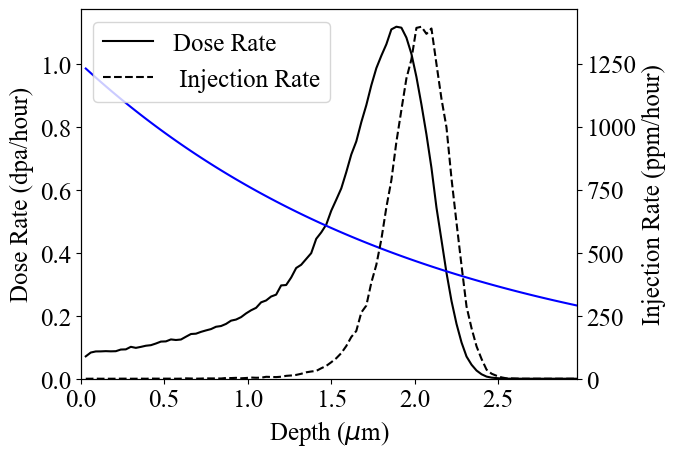

In [ ]:
#Plotting dose rate and injected interstitials for Si4+ irradiation

# Defining beam and calculating dose rate
current = 20*1e-9 #in A

charge = 4
C = 1.6*1e-19 #Coulomb constant
radius = np.sqrt(1)*1e7 #in Ang
flux = current/(charge*C*np.pi*(radius**2)) #in ions/Ang^2/s
print(flux*1e16)

Av = 6.022e23 #Avogadro's number atoms/mol
Mmol = 40.11 #molar mass in g/mol
rho = 3.21*1e-24 #g/cm^3 converted to g/Ang^3
N = 2*Av*rho/Mmol #in cm^-3

dose_rate = np.array([flux*x*3600/N for x in Si_damage_matrix[:, 1]])

fig, ax1 = plt.subplots()

font_size = 18

rcParams['font.family'] = 'Times New Roman'

depth = np.array([x * 1e-4 for x in Si_damage_matrix[:, 0]])
thermal_probe_depth = 6.4*1e4/np.pi

Si_injection_rate = Si_injected_ions_matrix[:, 1]*((1e-8)**1)*flux*3600*1e6/N

# First line on the left y-axis (Dose Rate)
ax1.plot([x * 1e-4 for x in Si_damage_matrix[:, 0]], dose_rate, color='black', label='Dose Rate')
ax1.plot(depth, np.exp(-depth/thermal_probe_depth/1e-4), color='b')
#ax1.plot([flux*x*3600/N for x in Si_damage_matrix[:, 0]], dose_rate, color='black', label='Dose Rate')
ax1.set_xlabel(r'Depth ($\mu$m)', fontsize=font_size, fontname='Times New Roman')
ax1.set_ylabel("Dose Rate (dpa/hour)", fontsize=font_size, color="black", fontname='Times New Roman')

# Set up secondary y-axis for the second line (Injected Interstitials)
ax2 = ax1.twinx()
ax2.plot(
    [x * 1e-4 for x in Si_injected_ions_matrix[:, 0]],
    Si_injection_rate,
    color="black",
    linestyle="--",
    #label="Injected \nInterstitials"
    label = " Injection Rate"
)
ax2.set_ylabel("Injection Rate (ppm/hour)", color="black", fontsize=font_size, fontname = 'Times New Roman')

# Third line on the left y-axis (Thermal Probe Depth as a vertical line)
#ax1.plot([thermal_probe_depth * 1e-4, thermal_probe_depth * 1e-4],[np.min(dose_rate), np.max(dose_rate)],color="magenta",label="Thermal Probe \nDepth")

#ax1.plot([acoustic_probe_depth * 1e-4, acoustic_probe_depth * 1e-4],[np.min(dose_rate), np.max(dose_rate)],color="red",linestyle='--',label="Acoustic Probe Depth")

# Combine legends from both y-axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=font_size, labelfontfamily='Times New Roman') 
ax2.tick_params(axis='both', which='major', labelsize=font_size, labelfontfamily='Times New Roman') 

ax1.set_ylim(0, 1.05*np.max(dose_rate))
ax2.set_ylim(0, 1.05*np.max(Si_injection_rate))
ax1.set_xlim(0, np.max(np.array([x * 1e-4 for x in Si_damage_matrix[:, 0]])))



plt.show()

The following section is used to read in the TGS results file and provide thermal diffusivity vs dose plots

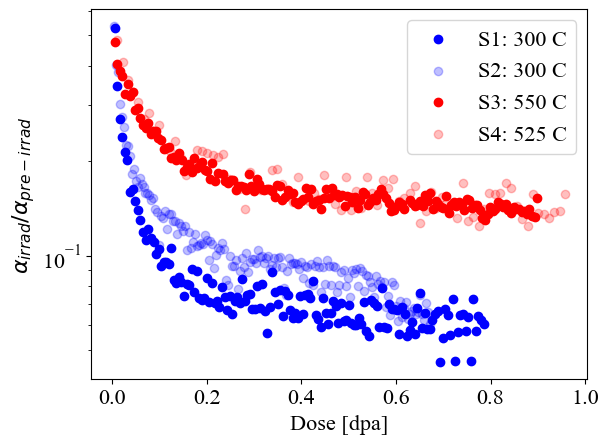

6854.298363733333 9.811666599955883
6978.144258816 9.16354291333933
6740.252479156667 16.55334572641317
6862.474206126 19.664353832908514
27.567096666666664 1.68535158 32.47154690000001 2.1793889699999998 16.612994583333332 2.2868791699999997 2.8515118099999994 0.23392840240889712
Dose Received 300C and 300 C V2
0.7554000000000001 0.6483125000000001
Dose Received 550C and 550 C V2
0.8681083333333334 0.8949700000000002
0.5570728769100756 0.3770833037012278


(0.95, 1.0)

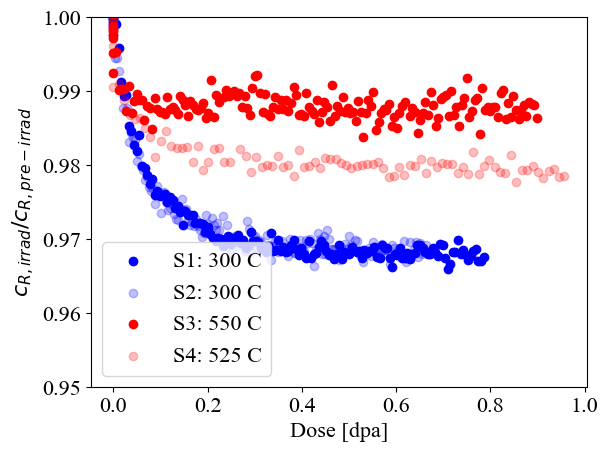

In [35]:
#Reading data from TGS experiment postprocessing file

#note grating spacing for 600 and 700 C is 6.65e-3

norm = 'yes'

def diff_calculator(folder_path, folder, file_name, start_time_index, end_time_index, dose_rate_per_hour, color, dose_offset, temp, alpha, plot):
    file_path = folder_path + folder


    time = []
    diff = []
    diff_err = []
    freq = []
    freq_err = []
    with open(file_path+file_name, 'r') as file:
        for line in file:
        #print(line)
            if "time (s) alpha[m^2s^-1] alpha_err[m2s-1]" not in line:
                parts = line.split()
                if float(parts[5]) > 0.1e9 and float(parts[0]) < end_time_index:
                    #print(parts)
                    time.append(datetime.strptime(parts[1], "%H:%M:%S"))
                    diff.append(float(parts[3])*1e6) #converting to float and to mm^2/s
                    diff_err.append(float(parts[4])*1e6) #converting to float and to mm^2/s
                    freq.append(float(parts[5]))
                    freq_err.append(float(parts[6]))
    
    time_difference_vec = []
    for i in time:
        time_difference = i - time[0]
        time_difference_vec.append(time_difference.total_seconds()/3600)



    dose_received = np.zeros([len(time_difference_vec)])

    for i in range(len(time_difference_vec)):
        #print(i, start_time_index, end_time_index)
        if i >= start_time_index and i < end_time_index:
            dose_received[i] = dose_rate_per_hour*(time_difference_vec[i] - time_difference_vec[start_time_index])
        #elif i >= end_time_index:
            #dose_received[i] = dose_rate_per_hour*(time_difference_vec[end_time_index] - time_difference_vec[start_time_index])
    
    diff_pre_irrad = np.mean(diff[0:start_time_index])
    diff_pre_irrad_std = np.std(diff[0:start_time_index])
    freq_pre_irrad = np.array(freq[0:start_time_index])
    freq_pre_irrad_std = np.std(freq[0:start_time_index])
    #print(np.where(np.array(freq_pre_irrad) > 0.8e9)[0])
    freq_pre_irrad_index = np.where(np.array(freq_pre_irrad) > 0.8e9)[0]
    #print(freq_pre_irrad_index)
    freq_pre_irrad = np.mean(freq_pre_irrad[freq_pre_irrad_index])

    window_size = 3
    weights = np.ones(window_size) / window_size
    sma = np.convolve(diff, weights, mode='valid')

    if plot == 'yes':
        if norm == 'no':
            plt.scatter(dose_offset + dose_received[start_time_index+1:end_time_index], np.array(diff[start_time_index+1:end_time_index]), marker='o', color = color, alpha=alpha)
            plt.xlabel("Dose [dpa]", fontsize=16, fontname='Times New Roman')
            plt.ylabel(r'$\alpha_{irrad}$ [$mm^2/s$]', fontsize=16, fontname='Times New Roman')
            plt.tick_params(axis='both', which='major', labelsize=16) 
            plt.xscale('log')
            plt.yscale('log')

        elif norm == 'yes':

            plt.scatter(dose_offset + dose_received[start_time_index+1:end_time_index], np.array(diff[start_time_index+1:end_time_index])/diff_pre_irrad, marker='o', color = color, alpha=alpha)
            plt.xlabel("Dose [dpa]", fontsize=16, fontname='Times New Roman')
            plt.ylabel(r'$\alpha_{irrad}/\alpha_{pre-irrad}$', fontsize=16, fontname='Times New Roman')
            plt.tick_params(axis='both', which='major', labelsize=16) 
            plt.yscale('log')
 




    return dose_received, diff, diff_pre_irrad, diff_err, freq, freq_pre_irrad, diff_pre_irrad_std, freq_pre_irrad_std

folder_path = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\"
file_name_300C = "PremaTech_CVD_SiC_HeandSi-2025-10-11-06.40um-spot04postprocessing_4.txt"
dose_received_300C, diff_300C, diff_300C_pre_irrad, diff_300C_err, freq_300C, freq_300C_pre_irrad, diff_pre_irrad_std_300C, freq_pre_irrad_std_300C = diff_calculator(folder_path, "PremaTech_CVD_SiC_HeandSi\\2025-10-11\\", file_name_300C, 9, 157, 0.3, 'b', 0, 300, 1, 'yes')
file_name_300C_v2 = "PremaTech_CVD_SiC_HeandSi-2025-10-31-06.40um-spot04postprocessing_4.txt"
dose_received_300C_v2, diff_300C_v2, diff_300C_pre_irrad_v2, diff_300C_err_v2, freq_300C_v2, freq_300C_pre_irrad_v2, diff_pre_irrad_std_300C_v2, freq_pre_irrad_std_300C_v2 = diff_calculator(folder_path, "PremaTech_CVD_SiC_HeandSi\\2025-10-31\\", file_name_300C_v2, 10, 173, 0.23, 'b', 0, 300, 0.25, 'yes')
file_name_550C = "PremaTech_CVD_SiC_HeandSi-2025-10-15-06.40um-spot04postprocessing_6.txt"
dose_received_550C, diff_550C, diff_550C_pre_irrad, diff_550C_err, freq_550C, freq_550C_pre_irrad, diff_pre_irrad_std_550C, freq_pre_irrad_std_550C = diff_calculator(folder_path, "PremaTech_CVD_SiC_HeandSi\\2025-10-15\\", file_name_550C, 12, 193, 0.3, 'r', 0, 550, 1, 'yes')
file_name_550C_v2 = "PremaTech_CVD_SiC_HeandSi-2025-11-01-06.40um-spot04postprocessing_6.txt"
dose_received_550C_v2, diff_550C_v2, diff_550C_pre_irrad_v2, diff_550C_err_v2, freq_550C_v2, freq_550C_pre_irrad_v2, diff_pre_irrad_std_550C_v2, freq_pre_irrad_std_550C_v2 = diff_calculator(folder_path, "PremaTech_CVD_SiC_HeandSi\\2025-11-01\\", file_name_550C_v2, 10, 98, 0.62, 'r', 0, 550, 0.25, 'yes')
#file_name_600C = "PremaTech_CVD_SiC_HeandSi-2025-06-21-06.40um-spot02postprocessing_3.txt"
#dose_received_600C, diff_600C, diff_600C_pre_irrad, diff_600C_err, freq_600C, freq_600C_pre_irrad = diff_calculator(folder_path, "PremaTech_CVD_SiC_HeandSi\\2025-06-21\\", file_name_600C, 21, 114, 0.3, 'm', 0, 600, 1, 'no')
#file_name_700C = "PremaTech_CVD_SiC_HeandSi-2025-06-21_2-06.40um-spot05postprocessing_4.txt"

plt.legend(['S1: 300 C', 'S2: 300 C', 'S3: 550 C', 'S4: 525 C'], fontsize=16)
plt.show()

# NOTE GRATING SPACING FOR 600 C and 700 C is 6.5813e-06
# NOTE GRATING SPACING FOR 550 C is 6.6604
# NOTE GRATING SPACING FOR 300 C V2 is 6.6512
# NOTE GRATING SPACING FOR 550 C V2 is 6.6234
# NOTE GRATING SPACING FOR 300 C is 6.6318

grating_300C = 6.6318*1e-6
grating_300C_v2 = 6.6512*1e-6
grating_550C = 6.6604*1e-6
grating_550C_v2 = 6.6234*1e-6

print(freq_300C_pre_irrad*grating_300C, freq_pre_irrad_std_300C*grating_300C)
print(freq_300C_pre_irrad_v2*grating_300C_v2, freq_pre_irrad_std_300C_v2*grating_300C_v2)
print(freq_550C_pre_irrad*grating_550C, freq_pre_irrad_std_550C*grating_550C)
print(freq_550C_pre_irrad_v2*grating_550C_v2, freq_pre_irrad_std_550C_v2*grating_550C_v2)





nominal_grating = 6.4e-3 #in mm
implantation_peak = 2e-3
sample_depth = 1 #in mm

depth_vec = np.arange(0, sample_depth, 1e-5)
grating_depth_index = np.where(depth_vec >= implantation_peak)[0][0]


diff_saturation_550C = np.mean(diff_550C[len(diff_550C) - 11: len(diff_550C)-1])
#diff_saturation_550C_err = np.mean(diff_550C_err[100:])
diff_saturation_550C_err = np.std(diff_550C[len(diff_550C) - 11: len(diff_550C)-1])
diff_saturation_300C = np.mean(diff_300C[len(diff_300C) - 11: len(diff_300C)-1])
#diff_saturation_300C_err = np.mean(diff_300C_err[100:])
diff_saturation_300C_err = np.std(diff_300C[len(diff_300C) - 11: len(diff_300C)-1])
diff_saturation_300C_v2 = np.mean(diff_300C_v2[len(diff_300C_v2) - 11: len(diff_300C_v2)-1])
#diff_saturation_300C_err_v2 = np.mean(diff_300C_err_v2[100:])
diff_saturation_300C_err_v2 = np.std(diff_300C_v2[len(diff_300C_v2) - 11: len(diff_300C_v2)-1])
diff_saturation_550C_v2 = np.mean(diff_550C_v2[len(diff_550C_v2) - 11: len(diff_550C_v2)-1])
#diff_saturation_550C_err_v2 = np.mean(diff_550C_err_v2[50:])
diff_saturation_550C_err_v2 = np.std(diff_550C_v2[len(diff_550C_v2) - 11: len(diff_550C_v2)-1])


print(diff_300C_pre_irrad, diff_saturation_300C, diff_300C_pre_irrad_v2, diff_saturation_300C_v2, diff_550C_pre_irrad, diff_saturation_550C, diff_saturation_550C_v2, diff_saturation_550C_err_v2)
print('Dose Received 300C and 300 C V2')
print(np.mean(dose_received_300C[len(diff_300C) - 11: len(diff_300C)-1]), np.mean(dose_received_300C_v2[len(diff_300C_v2) - 11: len(diff_300C_v2)-1]))
print('Dose Received 550C and 550 C V2')
print(np.mean(dose_received_550C[len(diff_550C) - 11: len(diff_550C)-1]), np.mean(dose_received_550C_v2[len(diff_550C_v2) - 11: len(diff_550C_v2)-1]))

defect_diffusivity_300C = 1/diff_saturation_300C - 1/diff_300C_pre_irrad
defect_diffusivity_550C = 1/diff_saturation_550C - 1/diff_550C_pre_irrad

print(defect_diffusivity_300C, defect_diffusivity_550C)


plt.scatter(dose_received_300C, freq_300C/freq_300C_pre_irrad, marker='o', color = 'b')
plt.scatter(dose_received_300C_v2, freq_300C_v2/freq_300C_pre_irrad_v2, marker='o', color = 'b', alpha=0.25)
plt.scatter(dose_received_550C, freq_550C/freq_550C_pre_irrad, marker='o', color = 'r')
plt.scatter(dose_received_550C_v2, freq_550C_v2/freq_550C_pre_irrad_v2, marker='o', color = 'r', alpha=0.25)
#plt.scatter(dose_received_550C_v2, freq_550C/freq_550C_pre_irrad, marker='o', color = 'b')
plt.xlabel("Dose [dpa]", fontsize=16, fontname='Times New Roman')
plt.ylabel(r'$c_{R,irrad}/c_{R,pre-irrad}$', fontsize=16, fontname='Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=16) 
#plt.xscale('log')
plt.legend(['S1: 300 C', 'S2: 300 C', 'S3: 550 C', 'S4: 525 C'], fontsize=16)
plt.ylim([0.95, 1])


Here we plot the thermal defect resistance. The suppression function is calculated based on the ratio between the TGS and LFA values

heat capacity [J/kg/K]: 1018.463825714 at temperature [K]: 573.000000000
heat capacity [J/kg/K]: 1135.236508968 at temperature [K]: 823.000000000
heat capacity [J/kg/K]: 660.104595111 at temperature [K]: 294.000000000
1018.4638257141785 1135.2365089677728 660.1045951114481
214.29336762027214 174.9322137671652 147.78689130274142 125.4075746175069 119.88251513516751
heat capacity [J/kg/K]: 676.721134444 at temperature [K]: 300.000000000
heat capacity [J/kg/K]: 676.721134444 at temperature [K]: 300.000000000
heat capacity [J/kg/K]: 676.721134444 at temperature [K]: 300.000000000
heat capacity [J/kg/K]: 676.721134444 at temperature [K]: 300.000000000
heat capacity [J/kg/K]: 676.721134444 at temperature [K]: 300.000000000
heat capacity [J/kg/K]: 676.721134444 at temperature [K]: 300.000000000
0.6507813188542649 0.766561541548631 0.6498589650811036 0.7654606488434965
heat capacity [J/kg/K]: 1018.463825714 at temperature [K]: 573.000000000
heat capacity [J/kg/K]: 1018.463825714 at temperature

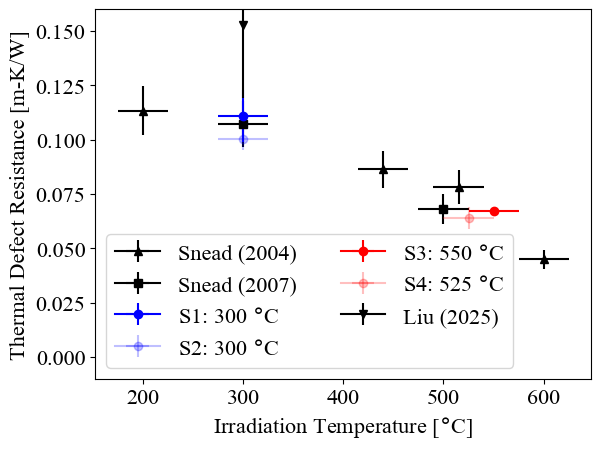

In [69]:
# In this plot, data from Figure 23 of Snead et al., 2007 is replotted and anaylzed

rho_SiC_RT = 3210 # in kg/m^3

dose_200C = [0.001, 0.010444026548079704, 0.055626655456896476, 0.09785113510926954, 2.490155557241004]
K_200C = [183.40415528459005, 50.20481264890657, 13.849073359997714, 11.339664788501697, 8.630915576058177]

dose_440C = [0.04936236906610374, 0.04936236906610374, 0.09891974619206832, 0.4990146529094564, 0.49362389313594635, 0.9891978676703855]
K_440C = [18.62009772528618, 16.401527846556522, 12.388006826727738, 12.923124957285312, 11.8750559541807, 11.25281117295849]

dose_515C = [0.050446407708308695, 0.04936236906610374, 0.09891974619206832, 0.10000002734537793, 0.4990146529094564, 0.4882913687083645, 1.4784652120252206, 6.067633746400251]
K_515C = [17.576705565704135, 15.72238280362122, 17.50926037487044, 15.72238280362122, 17.917834673378696, 14.671185018367485, 12.388006826727738, 13.27561888614122]

dose_600C = [0.10000002734537793, 0.9999995898194733]
K_600C = [30.224195469857204, 21.057647215446586]

def heat_capacity_calculator (temp):
    heat_capacity = 925.65 + 0.3772*temp - 7.9259*1e-5*(temp**2) - (3.1946*1e7)/(temp**2) # also from Snead et al, 2007
    return heat_capacity

K_unirrad = 381 
alpha_unirrad = K_unirrad/rho_SiC_RT/heat_capacity_calculator(300)

# the data below is from Snead et al, 2004 (Limits), figure 2

dose_300C = [0.010438381689873516, 0.09718011650450926, 0.5954491780467286, 1.389495494373136, 2.300389544491268, 4.061587895958285, 4.719688866685861]
K_300C = [39.85680574653085, 9.999999999999998, 9.329305938298027, 9.115889020370902, 9.771243151720366, 9.547713710169202, 9.437878056716512]

dose_500C = [1.5139933180903655, 4.194410874163198]
K_500C = [14.149914962905418, 12.973745442815991]

# data below from fig 26 of the same paper and gives thermal diffusivity at approximately 7 dpa and beyond

temp_snead_sub_1273K = 273 + np.array([79.229, 202.48, 376.34, 400.55, 486.28, 550.20, 605.23, 803.30, 924.37, 1001.38]) # in K
K_snead_sub_1273K = np.array([4.77, 7.04, 8.18, 9.77, 12.5, 11.81, 16.36, 18.86, 20.45, 21.818]) #in W/m/K

# the calculation below shows the thermal conductivity as a function of temperature taken using Eq 12 in Snead et al., 2007

temperature_vec = np.arange(273, 1273, 1)

def heat_capacity_calculator (temp):
    heat_capacity = 925.65 + 0.3772*temp - 7.9259*1e-5*(temp**2) - (3.1946*1e7)/(temp**2) # also from Snead et al, 2007
    print(f"heat capacity [J/kg/K]: {heat_capacity:.9f} at temperature [K]: {temp:.9f}")
    return heat_capacity

def pre_irrad_K_calculator(temp):
    K_temp_K = 1/(-0.0003 + 1.05*1e-5*temp)
    return K_temp_K

temperatures_to_plot = np.array([200, 300, 440, 500, 515, 600]) # all in C

#shapes = ['^', '<', '>', 's']

print(heat_capacity_calculator(573), heat_capacity_calculator(823), heat_capacity_calculator(294))
print(pre_irrad_K_calculator(473), pre_irrad_K_calculator(573), pre_irrad_K_calculator(673), pre_irrad_K_calculator(788), pre_irrad_K_calculator(823))

handles, label = [], []

for i in range(len(temperatures_to_plot)):
    temperature = temperatures_to_plot[i]
    K_pre_irrad_temp = pre_irrad_K_calculator(temperature+273)
    if temperature in [200, 440, 515, 600]:
        if temperature == 200:
            dose = dose_200C[4]
            K = K_200C[4]
            alpha = K/heat_capacity_calculator(300)/rho_SiC_RT
            shape = '^'
            #label.append('Snead (2007)')
        elif temperature == 440:
            dose = dose_440C[5]
            K = K_440C[5]
            alpha = K/heat_capacity_calculator(300)/rho_SiC_RT
            shape = '^'
        elif temperature == 515:
            dose = dose_515C[6]
            K = K_515C[6]
            alpha = K/heat_capacity_calculator(300)/rho_SiC_RT
            shape = '^'
        elif temperature == 600:
            dose = dose_600C[1]
            K = K_600C[1]
            alpha = K/heat_capacity_calculator(300)/rho_SiC_RT
            shape = '^'
            label.append('Snead (2007)')
        
        #line1 = plt.errorbar(temperature, K/K_pre_irrad_temp, xerr= 25, yerr= 0.1*K/K_pre_irrad_temp, marker= shape, color='k') # error for temp is from thermal model in https://www.osti.gov/biblio/1474529 and error for K if 10% from Katoh et al. (2011) Stability
        defect_resistance = (1/K) - (1/K_unirrad)
        line1 = plt.errorbar(temperature, defect_resistance, xerr= 25, yerr= 0.1*defect_resistance, marker = shape, color='k') # error for temp is from thermal model in https://www.osti.gov/biblio/1474529 and error for K if 10% from Katoh et al. (2011) Stability
        

    elif temperature in [300, 500]:
        if temperature == 300:
            dose = dose_300C[3]
            K = K_300C[3]
            alpha = K/heat_capacity_calculator(300)/rho_SiC_RT
            shape = 's'
            #labels.append('Snead (2004)')
        elif temperature == 500:
            dose = dose_500C[0]
            K = K_500C[0]
            alpha = K/heat_capacity_calculator(300)/rho_SiC_RT
            shape = 's'
            label.append('Snead (2004)')
        
        #line2 = plt.errorbar(temperature, K/K_pre_irrad_temp, xerr= 25, yerr= 0.1*K/K_pre_irrad_temp, marker= shape, color='k') # error for temp is from thermal model in https://www.osti.gov/biblio/1474529 and error for K if 10% from Katoh et al. (2011) Stability
        defect_resistance = (1/K) - (1/K_unirrad)
        line2 = plt.errorbar(temperature, defect_resistance, xerr= 25, yerr= 0.1*defect_resistance, marker= shape, color='k') # error for temp is from thermal model in https://www.osti.gov/biblio/1474529 and error for K if 10% from Katoh et al. (2011) Stability
        
plt.xlabel(r"Irradiation Temperature [$\degree$C]", fontsize=16, fontname='Times New Roman')
plt.ylabel('Thermal Defect Resistance [m-K/W]', fontsize=16, fontname='Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=16) 
plt.legend(['300 C, this study', '500 C, this study', 'Snead (2007)', 'Snead (2004)'], fontsize = '16')

legend_font_properties = {'family': 'Times New Roman', 'size': 16}

plt.legend(handles, label, prop=legend_font_properties)
plt.ylim([0.03, 0.14])

diff_300C_LFA = LFA_diff[np.where(LFA_temp >= 300)[0][0]]
diff_550C_LFA = LFA_diff[np.where(LFA_temp >= 550)[0][0]]
diff_525C_LFA = LFA_diff[np.where(LFA_temp >= 525)[0][0]]
supression_300C = diff_300C_pre_irrad/diff_300C_LFA
supression_300C_v2 = diff_300C_pre_irrad_v2/diff_300C_LFA
supression_550C = diff_550C_pre_irrad/diff_550C_LFA
supression_550C_v2 = diff_550C_pre_irrad_v2/diff_525C_LFA

print(supression_300C, supression_300C_v2, supression_550C, supression_550C_v2)


defect_reistance_TGS_300C = (1/(rho_SiC_RT*heat_capacity_calculator(300+273)))*supression_300C*((1/diff_saturation_300C) - (1/diff_300C_pre_irrad))*(1e6)
defect_reistance_TGS_300C_v2 = (1/(rho_SiC_RT*heat_capacity_calculator(300+273)))*supression_300C_v2*((1/diff_saturation_300C_v2) - (1/diff_300C_pre_irrad_v2))*(1e6)
defect_reistance_TGS_550C = (1/(rho_SiC_RT*heat_capacity_calculator(550+273)))*supression_550C*((1/diff_saturation_550C) - (1/diff_550C_pre_irrad))*(1e6)
defect_reistance_TGS_550C_v2 = (1/(rho_SiC_RT*heat_capacity_calculator(525+273)))*supression_550C_v2*((1/diff_saturation_550C_v2) - (1/diff_550C_pre_irrad_v2))*(1e6)


#line3 = plt.errorbar(300, diff_saturation_300C/diff_300C_pre_irrad, yerr= diff_saturation_300C_err/diff_300C_pre_irrad, marker = 'o', color='g')
line3 = plt.errorbar(300, defect_reistance_TGS_300C, yerr= defect_reistance_TGS_300C*(diff_saturation_300C_err/diff_saturation_300C), xerr= 25, marker = 'o', color='b')
label.append(r'S1: 300 $\degree$C')
line4 = plt.errorbar(300, defect_reistance_TGS_300C_v2, yerr= defect_reistance_TGS_300C_v2*(diff_saturation_300C_err_v2/diff_saturation_300C_v2), xerr= 25, marker = 'o', color='b', alpha=0.25)
label.append(r'S2: 300 $\degree$C')
#line4 = plt.errorbar(550, diff_saturation_550C/diff_550C_pre_irrad, yerr= diff_saturation_550C_err/diff_550C_pre_irrad, marker = 'o', color='b')
line5 = plt.errorbar(550, defect_reistance_TGS_550C, yerr= defect_reistance_TGS_550C*(diff_saturation_550C_err/diff_saturation_550C), marker = 'o', xerr= 25, color='r')
label.append(r'S3: 550 $\degree$C')
line6 = plt.errorbar(525, defect_reistance_TGS_550C_v2, yerr= defect_reistance_TGS_550C_v2*(diff_saturation_550C_err_v2/diff_saturation_550C_v2), xerr= 25, marker = 'o', color='r', alpha=0.25)
label.append(r'S4: 525 $\degree$C')


plt.xlabel(r"Irradiation Temperature [$\degree$C]", fontsize=16, fontname='Times New Roman')
plt.ylabel('Thermal Defect Resistance [m-K/W]', fontsize=16, fontname='Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=16) 
#plt.legend(['300 C, this study', '500 C, this study', 'Snead (2007)', 'Snead (2004)'], fontsize = '16')

legend_font_properties = {'family': 'Times New Roman', 'size': 16}



print(heat_capacity_calculator(573), heat_capacity_calculator(298))
print(0.5*(defect_reistance_TGS_300C+ defect_reistance_TGS_300C_v2), 0.5*(defect_reistance_TGS_550C+ defect_reistance_TGS_550C_v2))

#in the lines below, we plot the thermal defect resistance at 0.85 dpa from the Han Liu paper

dose_liu = [0.8458573232403471, 0.8477841643061811, 0.8477841643061811]
thermal_defect_resistance_liu = [0.15259479675763418, 0.18572854747811238, 0.11866266868246858]
thermal_defect_resistance_liu_err = np.mean([thermal_defect_resistance_liu[1] - thermal_defect_resistance_liu[0], thermal_defect_resistance_liu[0] - thermal_defect_resistance_liu[2]])

line7 = plt.errorbar(300, thermal_defect_resistance_liu[0], yerr=thermal_defect_resistance_liu_err, marker = 'v', color='k', alpha=1)
label.append(r'Liu (2025)')
handles = [line1, line2, line3, line4, line5, line6, line7]
plt.legend(handles, label, prop=legend_font_properties, loc='lower left', ncol=2)
plt.ylim([-0.01, 0.16])

print(diff_saturation_300C_err)
print(diff_saturation_300C_err_v2)
print(diff_saturation_550C_err)
print(diff_saturation_550C_err_v2)


823 K
777
573 K
550
4.1
24.16462652305097 44.63443686384221
823 K
747
573 K
535
2.35
43.52650103064116 81.3717714021551


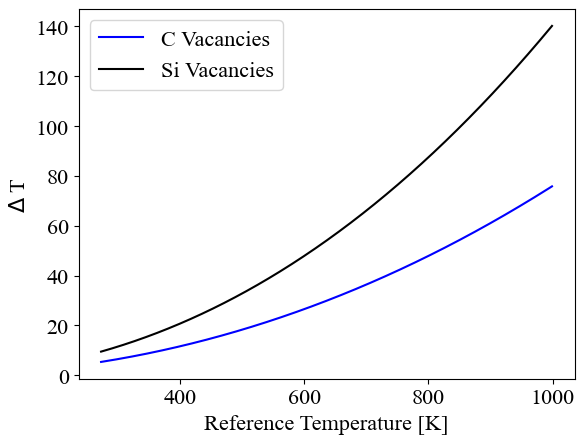

In [11]:
# To calculate Mansur temperature shift for point defects 

temperature_vec = np.arange(273, 1000, 1)
k_B = 8.6e-5

def temperature_shift (E_v_m, ion_irrad_temp):
    K_0_1 = 3.45e-6 #previously 1e-6
    K_0_2 = 1e-4
    T_2 = temperature_vec + ((k_B*(temperature_vec**2)/(E_v_m))*np.log(K_0_2/K_0_1))/(1-((k_B*(temperature_vec)/(E_v_m))*np.log(K_0_2/K_0_1)))
    low_temp_delta = ion_irrad_temp[0] - T_2
    high_temp_delta = ion_irrad_temp[1] - T_2
    print('823 K')
    print(temperature_vec[np.where(np.abs(high_temp_delta) <=1)[0][0]])
    print('573 K')
    print(temperature_vec[np.where(np.abs(low_temp_delta) <=1)[0][0]])   
    print(E_v_m)
    print(T_2[np.where(temperature_vec == 573)[0][0]] - 573, T_2[np.where(temperature_vec == 773)[0][0]] - 773)    
    return T_2

#E_v_m values taken from Atomistic study of intrinsic defect migration in 3C-SiC, Gao et al. 
T_2_V_C = temperature_shift(4.1, [573, 823])
T_2_V_Si = temperature_shift(2.35, [573, 823])

rcParams['font.family'] = 'Times New Roman'
font_size = 16
plt.plot(temperature_vec, T_2_V_C - temperature_vec, 'b')
plt.plot(temperature_vec, T_2_V_Si - temperature_vec, 'k')
plt.ylabel(r'$\Delta$ T', fontsize = font_size)
plt.xlabel('Reference Temperature [K]', fontsize = font_size)
plt.tick_params(axis='both', which='major', labelsize = font_size) 
plt.legend(['C Vacancies', 'Si Vacancies'], fontsize=16)

In the section below, we plot the effective thermal conductivity as a function of grating spacing for a single crystal and polycrystalline (3.5 um grains) 3C-SiC - this is with mass and radius difference (e=1)

0
1
2
3
4
0
1
2
3
4


C:\Users\keshav98\AppData\Local\Temp\ipykernel_25316\2003814068.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\keshav98\AppData\Local\Temp\ipykernel_25316\2003814068.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


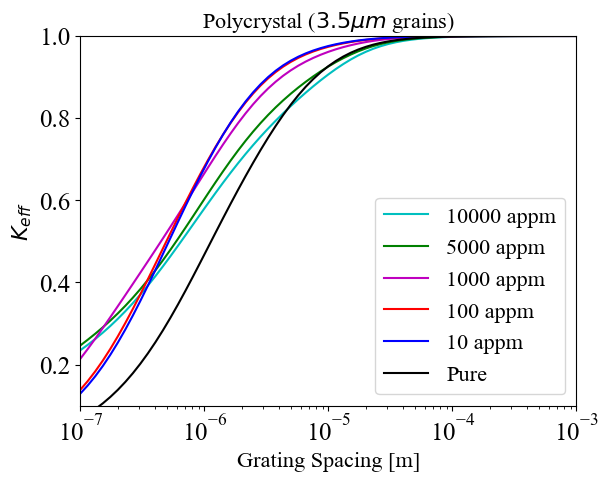

0
1
2
3
4


C:\Users\keshav98\AppData\Local\Temp\ipykernel_25316\2003814068.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


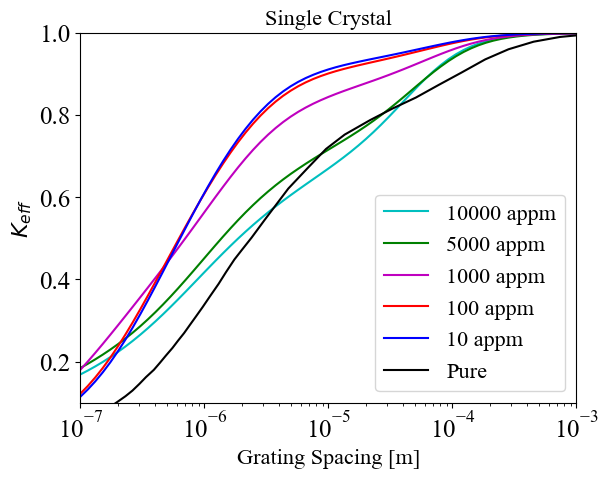

In [18]:
# In the section below, we plot the effective thermal conductivity as a function of grating spacing for a single crystal and polycrystalline (3.5 um grains) 3C-SiC

folder = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\SiC_phase_study\\Final_results_20250831\\"

file_name_single = "keff_modelling_results.txt"
file_name_grains = "keff_modelling_results_grains.txt"
file_name_grains_and_vacancies = "keff_modelling_results_vacancies_and_grains.txt"
file_name_grains_and_vacancies_e1 = "keff_modelling_results_vacancies_and_grains_e1.txt"
file_name_single_vacancies_e1 = "keff_modelling_results_vacancies_e1.txt"

def plotter (file_name):
    if file_name == "keff_modelling_results.txt":
        grating = []
        keff = []
        with open(folder+file_name, 'r') as file:
            for line in file:
            #print(line)
                if "grating_period_m" not in line:
                    parts = line.split(',')
                    #print(parts)
                    grating.append(float(parts[0]))
                    keff.append(float(parts[1]))
        #plt.plot(grating, keff, color = 'k')
    elif file_name == "keff_modelling_results_vacancies_and_grains.txt":
        grating = []
        keff_grains = []
        keff_100000 = []
        keff_50000 = []
        keff_1000 = []
        keff_100 = []
        keff_10 = []
        with open(folder+file_name, 'r') as file:
            for line in file:
            #print(line)
                if "grating_period_m" not in line:
                    parts = line.split(',')
                    #print(parts)
                    grating.append(float(parts[0]))
                    keff_grains.append(float(parts[1]))
                    keff_100000.append(float(parts[2]))
                    keff_50000.append(float(parts[3]))
                    keff_1000.append(float(parts[4]))
                    keff_100.append(float(parts[5]))
                    keff_10.append(float(parts[6]))
        keff = np.column_stack([keff_grains, keff_100000, keff_50000, keff_1000, keff_100, keff_10])

    elif file_name == "keff_modelling_results_vacancies_and_grains_e1.txt":
        bulk = np.array([418.45, 20.974, 30.163, 78.332, 161.99])
        grating = []
        #keff_grains = []
        keff_100000 = []
        keff_50000 = []
        keff_1000 = []
        keff_100 = []
        keff_10 = []
        with open(folder+file_name, 'r') as file:
            for line in file:
            #print(line)
                if "grating_period_m" not in line:
                    parts = line.split(',')
                    #print(parts)
                    grating.append(float(parts[0]))
                    #keff_grains.append(float(parts[1]))
                    keff_100000.append(float(parts[1]))
                    keff_50000.append(float(parts[2]))
                    keff_1000.append(float(parts[3]))
                    keff_100.append(float(parts[4]))
                    keff_10.append(float(parts[5]))
        keff = np.column_stack([keff_100000, keff_50000, keff_1000, keff_100, keff_10])

    elif file_name == "keff_modelling_results_vacancies_e1.txt":
        grating = []
        #keff_grains = []
        keff_100000 = []
        keff_50000 = []
        keff_1000 = []
        keff_100 = []
        keff_10 = []
        with open(folder+file_name, 'r') as file:
            for line in file:
            #print(line)
                if "grating_period_m" not in line:
                    parts = line.split(',')
                    #print(parts)
                    grating.append(float(parts[0]))
                    #keff_grains.append(float(parts[1]))
                    keff_100000.append(float(parts[1]))
                    keff_50000.append(float(parts[2]))
                    keff_1000.append(float(parts[3]))
                    keff_100.append(float(parts[4]))
                    keff_10.append(float(parts[5]))
        keff = np.column_stack([keff_100000, keff_50000, keff_1000, keff_100, keff_10])
        #plt.plot(grating, keff_grains, color='k', linestyle = '--')
        #plt.plot(grating, keff_1000, color='b')
        #plt.plot(grating, keff_100, color = 'm')
        #plt.plot(grating, keff_10, color='r')

    return grating, keff



    
    #plt.plot(grating, keff)

    #return keff

grating_single, keff_single = plotter(file_name_single)
grating_vacancies_grains, keff_vacancies_grains = plotter(file_name_grains_and_vacancies)
grating_vacancies_grains_e1, keff_vacancies_grains_e1 = plotter(file_name_grains_and_vacancies_e1)
grating_vacancies_e1, keff_vacancies_e1 = plotter(file_name_single_vacancies_e1)

#colors = ['b','r','m','c']
colors = ['c', 'g', 'm', 'r', 'b']

x = grating_vacancies_grains_e1
Y = keff_vacancies_grains_e1[:, [0, 1, 2, 3, 4]]  # shape (N, 4)

size= np.shape(Y)

for i in range(size[1]):
    print(i)
    ax = plt.gca()
    ax.plot(x, Y[:, i], color=colors[i])
ax.legend()

plt.plot(grating_vacancies_grains, keff_vacancies_grains[:, 0], 'k', linewidth=1.5)

x = grating_vacancies_grains
Y = keff_vacancies_grains[:, [1, 2, 3, 4, 5]]

size= np.shape(Y)

for i in range(size[1]):
    print(i)
    ax = plt.gca()
    #ax.plot(x, Y[:, i], color=colors[i], linestyle='--')
ax.legend()

plt.legend(['10000 appm', '5000 appm', '1000 appm', '100 appm', '10 appm', 'Pure'], prop=legend_font_properties)

#plt.plot(grating_vacancies_grains_e1, keff_vacancies_grains_e1, color=color)
#plt.plot(grating_vacancies_grains_e1, keff_vacancies_grains[:, 1:])

#plt.plot([6.4e-6, 6.4e-6], [0, 1], color = 'g')


plt.xscale('log')
#plt.yscale('log')
plt.ylim([1e-1, 1])
plt.xlim([1e-7, 1e-3])
plt.title(r'Polycrystal ($3.5 \mu m$ grains)', font='Times New Roman', fontsize=16)


plt.xlabel('Grating Spacing [m]', fontdict = font_properties)
plt.ylabel(r'$K_{eff}$', fontdict = font_properties)
plt.tick_params(axis='both', which='major', labelsize=font_size) 
plt.show()
plt.legend(['Single Crystal', r'Polycrystal, $3.5$ $\mu m$ grains', r'Polycrystal, 1000 ppm vacancies', r'Polycrystal, 100 ppm vacancies'], prop=legend_font_properties)

x = grating_vacancies_e1
Y = keff_vacancies_e1[:, [0, 1, 2, 3, 4]]  # shape (N, 4)

size= np.shape(Y)

for i in range(size[1]):
    print(i)
    ax = plt.gca()
    ax.plot(x, Y[:, i], color=colors[i])
ax.legend()

plt.plot(grating_single, keff_single, 'k', linewidth=1.5)
#plt.plot([6.4e-6, 6.4e-6], [0, 1], color = 'g')

plt.legend(['10000 appm', '5000 appm', '1000 appm', '100 appm', '10 appm', 'Pure'], prop=legend_font_properties)
plt.xscale('log')
#plt.yscale('log')
plt.ylim([1e-1, 1])
plt.xlim([1e-7, 1e-3])
plt.title('Single Crystal', font='Times New Roman', fontsize=16)

plt.xlabel('Grating Spacing [m]', fontdict = font_properties)
plt.ylabel(r'$K_{eff}$', fontdict = font_properties)
plt.tick_params(axis='both', which='major', labelsize=font_size) 



In the following section, we plot K_irr/K_0 vs vacancy concentration for the bulk, 4.9, 6.4 and 7.5 um cases with a small supercell 

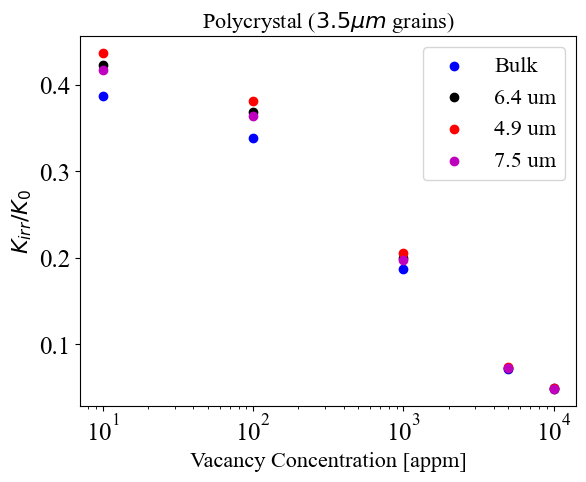

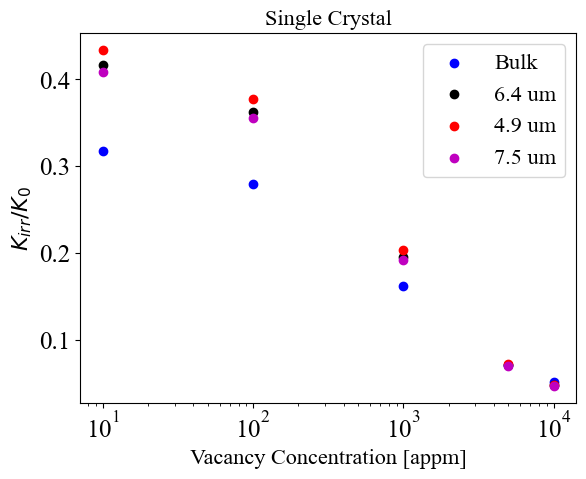

In [19]:
concentration = [10000, 5000, 1000, 100, 10]

# For e =1, polycrystal, 6.4 um grating

k_vacancies_grains_e1_bulk = np.array([20.794, 30.163, 78.332, 141.72, 161.99])
k_grains_unirradiated_bulk = 418.45
k_vacancies_grains_e1_6_4_norm = np.array([0.86198,0.88841,0.93768,0.95506,0.95762])
k_grains_unirradiated_6_4_norm = 0.87636
k_grains_unirradiated_6_4 = k_grains_unirradiated_6_4_norm*k_grains_unirradiated_bulk
k_vacancies_grains_e1_7_5_norm = np.array([0.87745,0.90163,0.94657,0.96226,0.96459])
k_grains_unirradiated_7_5_norm = 0.89511
k_grains_unirradiated_7_5 = k_grains_unirradiated_7_5_norm*k_grains_unirradiated_bulk
k_vacancies_grains_e1_4_9_norm = np.array([0.82917,0.85928,0.91618,0.93679,0.93979])
k_grains_unirradiated_4_9_norm = 0.83248
k_grains_unirradiated_4_9 = k_grains_unirradiated_4_9_norm*k_grains_unirradiated_bulk

plt.scatter(concentration, k_vacancies_grains_e1_bulk/k_grains_unirradiated_bulk, color='b')
plt.scatter(concentration, k_vacancies_grains_e1_6_4_norm*k_vacancies_grains_e1_bulk/k_grains_unirradiated_6_4, color='k')
plt.scatter(concentration, k_vacancies_grains_e1_4_9_norm*k_vacancies_grains_e1_bulk/k_grains_unirradiated_4_9, color='r')
plt.scatter(concentration, k_vacancies_grains_e1_7_5_norm*k_vacancies_grains_e1_bulk/k_grains_unirradiated_7_5, color='m')
plt.xscale('log')
#plt.yscale('log')
plt.legend(['Bulk', '6.4 um', '4.9 um', '7.5 um'], prop=legend_font_properties)

plt.xlabel('Vacancy Concentration [appm]', fontdict = font_properties)
plt.ylabel(r'$K_{irr}/K_0$', fontdict = font_properties)
plt.tick_params(axis='both', which='major', labelsize=font_size)
plt.title(r'Polycrystal ($3.5 \mu m$ grains)', font='Times New Roman', fontsize=16)
plt.show()

k_vacancies_e1_bulk = np.array([29.192,40.354,93.067,160.45,182.07])
k_vacancies_e1_6_4_norm = np.array([0.63121,0.68153,0.81844,0.87976,0.89025])
k_unirradiated_bulk = 573.9
k_unirradiated_6_4_norm = 0.67871
k_unirradiated_6_4 = k_unirradiated_6_4_norm*k_unirradiated_bulk
k_vacancies_e1_7_5_norm = np.array([0.64399,0.69319,0.82783,0.88796,0.89822])
k_unirradiated_7_5_norm = 0.69819
K_unirradiated_7_5 = k_unirradiated_7_5_norm*k_unirradiated_bulk
k_vacancies_e1_4_9_norm = np.array([0.60517,0.65679,0.79629,0.8595,0.87025])
k_unirradiated_4_9_norm = 0.63613
k_unirradiated_4_9 = k_unirradiated_4_9_norm*k_unirradiated_bulk

plt.scatter(concentration, k_vacancies_e1_bulk/k_unirradiated_bulk, color='b')
plt.scatter(concentration, k_vacancies_e1_6_4_norm*k_vacancies_e1_bulk/k_unirradiated_6_4, color='k')
plt.scatter(concentration, k_vacancies_e1_4_9_norm*k_vacancies_e1_bulk/k_unirradiated_4_9, color='r')
plt.scatter(concentration, k_vacancies_e1_7_5_norm*k_vacancies_e1_bulk/K_unirradiated_7_5, color='m')
plt.xscale('log')
#plt.yscale('log')
plt.legend(['Bulk', '6.4 um', '4.9 um', '7.5 um'], prop=legend_font_properties)

plt.xlabel('Vacancy Concentration [appm]', fontdict = font_properties)
plt.ylabel(r'$K_{irr}/K_0$', fontdict = font_properties)
plt.tick_params(axis='both', which='major', labelsize=font_size)
plt.title(r'Single Crystal', font='Times New Roman', fontsize=16)
plt.show()


In the section below, cumulative thermal conductivity is plotted as a function of phonon MFP

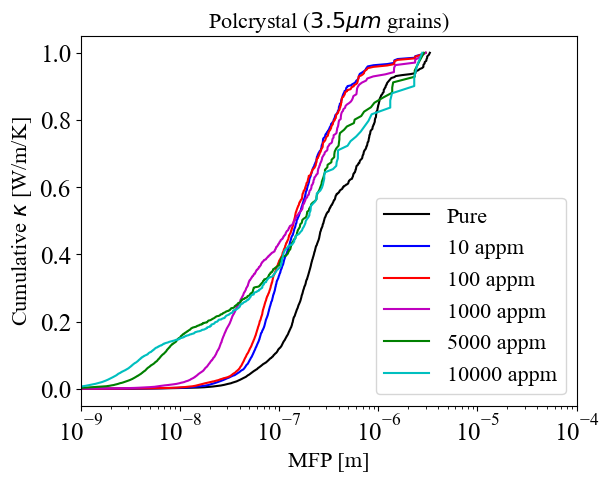

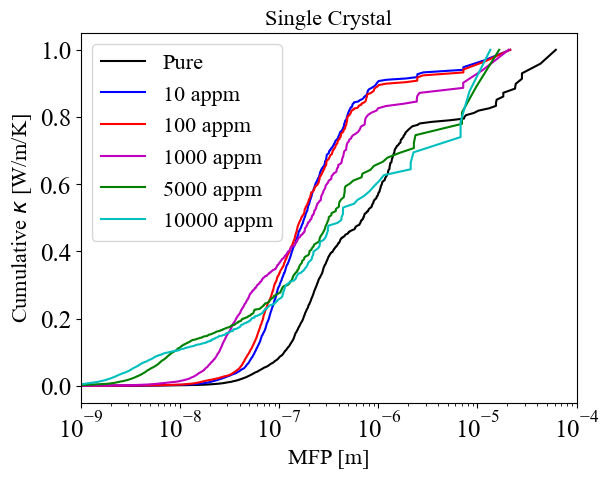

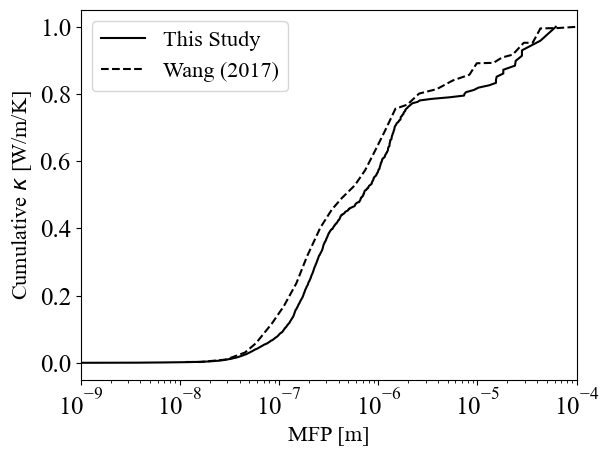

In [70]:
concentration_vec_ppm = np.array([0, 10, 100, 1000, 5000, 10000])
colors = ['k', 'b','r','m', 'g', 'c']

folder = "3CSiC_MFP\\"
file_prefix = "3CSiC_300K_MFP."

grains_text = ["wgrains", "nograins"]

for i in grains_text:
    for j in concentration_vec_ppm:
        index = np.where(concentration_vec_ppm == j)[0][0]
        if j/1e4 >= 1:
            filename = folder + file_prefix + str(int(j/1e4)) + "." + i + ".txt"
        elif j/1e4 < 1 and j/1e4 > 0:
            filename = folder + file_prefix + str(j/1e4) + "." + i + ".txt"
        elif j == 0:
            filename = folder + file_prefix + "pure" + "." + i + ".txt"
        mfp = []
        cum_K = []
        with open(filename, 'r') as file:
            for line in file:
                parts = line.split(',')
                mfp.append(float(parts[0])) 
                cum_K.append(float(parts[1]))
        if i == "nograins" and j == 0:
            cum_K_pure_nograins = cum_K
            mfp_K_pure_nograins = mfp
        plt.plot(mfp, cum_K, color = colors[index])
        if i == "nograins":
            plt.title(r'Single Crystal', font='Times New Roman', fontsize=16)

            #plt.plot(mfp_nm*1e-9, cum_K_wang/np.max(cum_K_wang), color = 'k', linestyle = '--')
            plt.legend(['Pure', '10 appm', '100 appm', '1000 appm', '5000 appm', '10000 appm'], prop=legend_font_properties)


        elif i == "wgrains":
            plt.title(r'Polcrystal ($3.5 \mu m$ grains)', font='Times New Roman', fontsize=16)
            plt.legend(['Pure', '10 appm', '100 appm', '1000 appm', '5000 appm', '10000 appm'], prop=legend_font_properties)
        
        
        
        plt.xscale('log')
        plt.xlim([1e-9, 1e-4])
        plt.xlabel('MFP [m]', fontdict = font_properties)
        plt.ylabel(r'Cumulative $\kappa$ [W/m/K]', fontdict = font_properties)
        plt.tick_params(axis='both', which='major', labelsize=font_size)


    plt.show()

# Below we have data from Wang et al which is plotted for comparison

mfp_nm = np.array([11.571081917588568, 16.033654094317423, 21.839146180150937, 29.24041900593443, 45.30066294126282, 58.60579674855224, 84.76927182619636, 111.565631802378, 149.37489559318945, 191.59581880828605, 260.96915087764387, 340.52797347743916, 429.34385028417137, 579.802938452663, 737.3282005986412, 921.6909381224161, 1152.1520331478628, 1490.5474554676027, 1961.7217567813088, 2581.8381272683905, 3898.2239665391276, 5638.518901707044, 8296.957745450305, 9850.907089322694, 14495.395209143157, 17659.228263291614, 22650.563274179014, 29303.223591377267, 36006.749067008444, 43119.05523089288, 65103.90126333336, 100862.09389451494])
cum_K_wang = np.array([1.201899326542437, 1.201899326542437, 3.004778577177977, 4.8077183494573985, 15.024013929177311, 28.846128531812408, 57.6923175852687, 82.93268761581002, 116.58647397543595, 156.2499385327054, 198.31732278634743, 224.7595921434312, 241.58654584488798, 260.2163485361585, 282.451879467878, 310.09616919479186, 338.3413480633331, 372.59614460787407, 378.6057622838738, 394.83170580041553, 401.4423034005084, 414.06248841577906, 422.4759652665075, 439.30288870714236, 439.90382324000257, 447.7163504274599, 451.92307372241305, 469.3509619567301, 469.3509619567301, 490.38459356190725, 490.9855734860004, 492.7884678670469])


K_pure_no_grains = 573.9
#plt.plot(mfp_K_pure_nograins, np.array(cum_K_pure_nograins)*K_pure_no_grains, 'k', linestyle='-')
#plt.plot(mfp_nm*1e-9, cum_K_wang, 'k', linestyle='--')
plt.plot(mfp_K_pure_nograins, np.array(cum_K_pure_nograins), 'k', linestyle='-')
plt.plot(mfp_nm*1e-9, cum_K_wang/np.max(cum_K_wang), 'k', linestyle='--')
plt.xscale('log')

plt.xlim([1e-9, 1e-4])
plt.xlabel('MFP [m]', fontdict = font_properties)
plt.ylabel(r'Cumulative $\kappa$ [W/m/K]', fontdict = font_properties)
plt.tick_params(axis='both', which='major', labelsize=font_size)
plt.legend(['This Study', 'Wang (2017)'], prop=legend_font_properties)


In this section we plot the suppression function per Fuchs-Sondheimer

C:\Users\keshav98\AppData\Local\Temp\ipykernel_28972\1799147135.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(y, t)


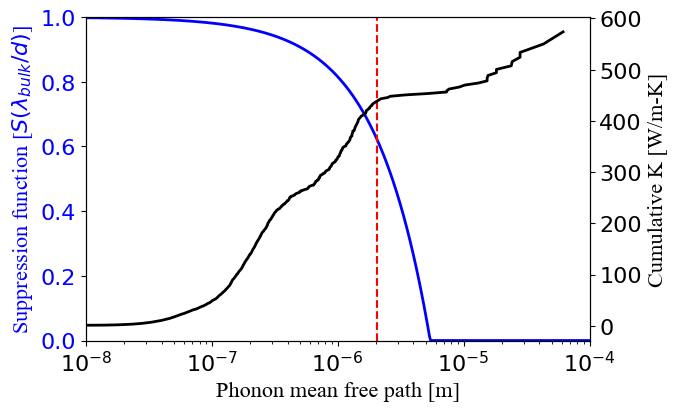

In [8]:
font_size = 16
mfp_array = np.logspace(-11, -2, 1000)
theta = np.arange(-np.pi, np.pi, 0.01)
t = 1/np.cos(theta)
t = np.logspace(1, 10, 1000)
grating_period = 6.4e-6
d = grating_period/np.pi

S_array = []

for i in range(len(mfp_array)):
    mfp = mfp_array[i]
    y = ((1/t**3) - (1/t**5))*np.exp(-grating_period*t/mfp)
    integral = np.trapz(y, t)
    S = 1 - (3*mfp/8/d) + (3/2)*(mfp/d)*integral
    if S <= 0:
        S = 0
    S_array.append(S)

mfp_nm = np.array([11.571081917588568, 16.033654094317423, 21.839146180150937, 29.24041900593443, 45.30066294126282, 58.60579674855224, 84.76927182619636, 111.565631802378, 149.37489559318945, 191.59581880828605, 260.96915087764387, 340.52797347743916, 429.34385028417137, 579.802938452663, 737.3282005986412, 921.6909381224161, 1152.1520331478628, 1490.5474554676027, 1961.7217567813088, 2581.8381272683905, 3898.2239665391276, 5638.518901707044, 8296.957745450305, 9850.907089322694, 14495.395209143157, 17659.228263291614, 22650.563274179014, 29303.223591377267, 36006.749067008444, 43119.05523089288, 65103.90126333336, 100862.09389451494])
cum_K = np.array([1.201899326542437, 1.201899326542437, 3.004778577177977, 4.8077183494573985, 15.024013929177311, 28.846128531812408, 57.6923175852687, 82.93268761581002, 116.58647397543595, 156.2499385327054, 198.31732278634743, 224.7595921434312, 241.58654584488798, 260.2163485361585, 282.451879467878, 310.09616919479186, 338.3413480633331, 372.59614460787407, 378.6057622838738, 394.83170580041553, 401.4423034005084, 414.06248841577906, 422.4759652665075, 439.30288870714236, 439.90382324000257, 447.7163504274599, 451.92307372241305, 469.3509619567301, 469.3509619567301, 490.38459356190725, 490.9855734860004, 492.7884678670469])

fig, ax1 = plt.subplots(figsize=(6.5, 4.2))

# Left y-axis: S_array in blue
line1, = ax1.plot(mfp_array, S_array, color='b', lw=2, label='Suppression S(λ)')
ax1.plot([d, d], [0, 1.1], 'r', linestyle='--')
ax1.set_xlabel('Phonon mean free path [m]', fontdict = font_properties)
ax1.set_ylabel(r'Suppression function [$S(\lambda_{bulk}/d)$]', color='b', fontdict = font_properties)
ax1.tick_params(axis='y', labelcolor='b', labelsize=font_size)
ax1.tick_params(axis='x', labelcolor='k', labelsize=font_size)
ax1.set_ylim([0, 1])
ax1.set_xlim([1e-8, 1e-4])
ax1.set_xscale('log')

# Right y-axis: cumulative κ in black
ax2 = ax1.twinx()
#line2, = ax2.plot(mfp_nm*1e-9, cum_K, color='k', lw=2, label='Cumulative κ')
line2, = ax2.plot(mfp_K_pure_nograins, np.array(cum_K_pure_nograins)*K_pure_no_grains, color='k', lw=2, label='Cumulative K [W/m/K]')
ax2.set_ylabel('Cumulative K [W/m-K]', color='k', fontdict = font_properties)
ax2.tick_params(axis='y', labelcolor='k', labelsize=font_size)

#plt.plot(mfp_array, S_array, 'b')
#plt.plot([d, d], [0, 1.1], 'r', linestyle='--')
#plt.xscale('log')
#plt.xlim([1e-11, 1e-5])
#plt.ylim([0, 1.1])
#plt.ylabel(r'$S(\lambda_{bulk}/d)$', fontdict = font_properties)
#plt.xlabel('Phonon MFP [m]', fontdict = font_properties)
#plt.tick_params(axis='both', which='major', labelsize=font_size) 

#plt.yscale('log')
#plt.yscale('log')

In the following section, we plot the thermal diffusivity as a function of grating period  

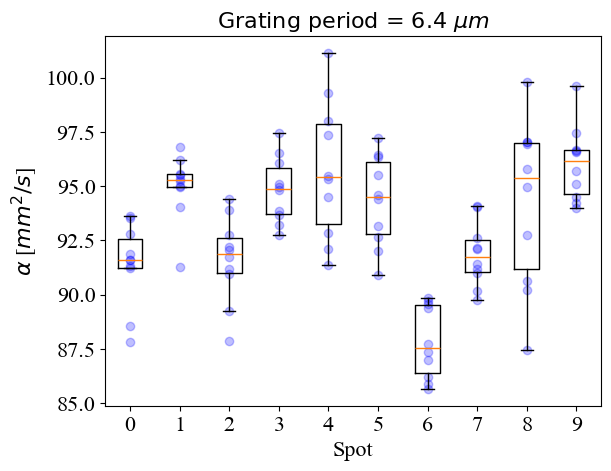

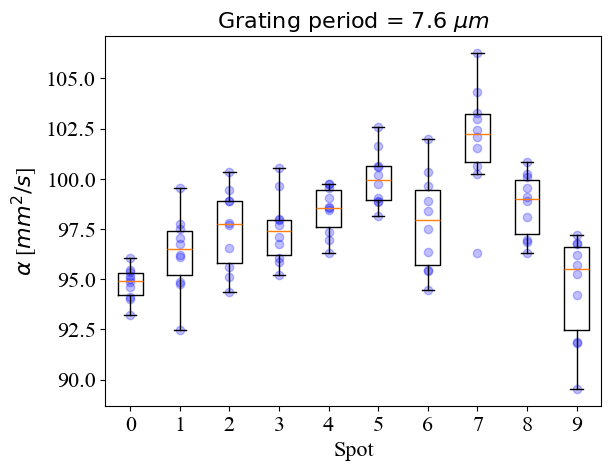

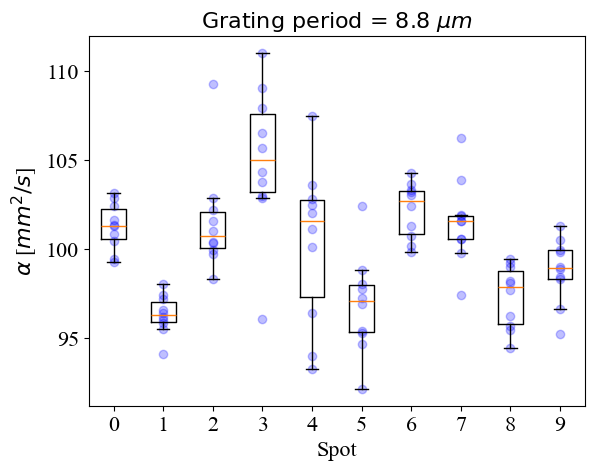

[ 93.29488153  97.75690062 100.1373316 ] [2.43149643 2.14750485 2.6038198 ]


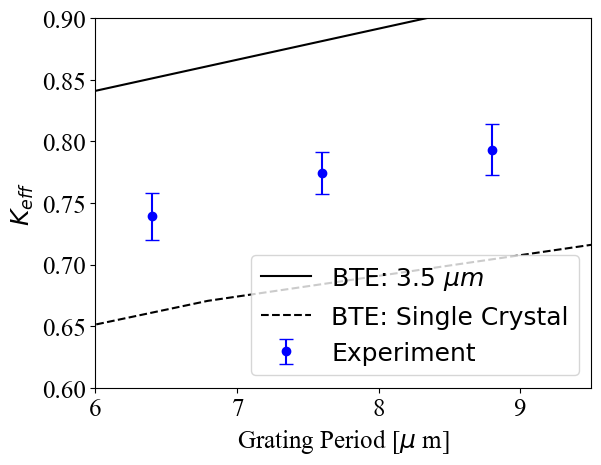

In [5]:
grating_period_6_40 = 6.6381e-06 # in m
grating_period_7_60 = 7.8717e-06 # in m
grating_period_8_80 = 9.0843e-06 # in m

folder = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\SiC_phase_study\\2025-11-07\\"


spots = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

nominal_grating = np.array([6.4, 7.6, 8.8])
diff_array = []
diff_err_array = []
for i in range(len(nominal_grating)):
    diff_array_sub = []
    if nominal_grating[i] == 6.4:
        grating = '06.40'
    elif nominal_grating[i] == 7.6:
        grating = '07.60'
    elif nominal_grating[i] == 8.8:
        grating = '08.80'
    for j in spots:
        filename = "SiC_phase_study-2025-11-07-" + grating + "um-spot" + f"{j:02d}" + "postprocessing.txt"
        diff = []
        freq = []
        with open(folder+filename, 'r') as file:
            for line in file: 
                if len(line) > 1:
                    parts = line.split()
                    diff.append(float(parts[3])*1e6)
                    freq.append(float(parts[5]))
        plt.boxplot(diff, positions=[j], patch_artist=False, widths=0.5,flierprops=dict(marker='', linestyle='none', color='r')) # this line will give the median as center line
        plt.scatter(np.ones(len(diff))*j, diff, alpha=0.25, color='b')
        diff_array_sub.append(np.mean(diff))
    plt.xlabel('Spot', fontsize=16, font='Times New Roman')
    plt.ylabel(r'$\alpha$ [$mm^2/s$]', fontsize=16, font='Times New Roman')
    plt.tick_params(axis='both', which='major', labelsize=16, labelfontfamily='Times New Roman') 
    plt.title("Grating period = " + str(nominal_grating[i]) + " " + r"$\mu m$", fontsize = 16)
    plt.show()
    diff_array.append(np.mean(diff_array_sub))
    diff_err_array.append(np.std(diff_array_sub))
    

#plt.errorbar(nominal_grating, diff_array, yerr=diff_err_array)




modeling_file_name = 'keff_modelling_results_grains.txt'

grating_spacing_grains = []
keff_grains = []
with open(folder + modeling_file_name, 'r') as file:
        for line in file:
            if "grating_period_m, k_eff" not in line:
                parts = line.split(', ')
                #print(parts, temperatures_string[i])
                #temperature.append(float(parts[0]))
                grating_spacing_grains.append(float(parts[0])) #converting to float and to mm^2/s
                keff_grains.append(float(parts[1])) #converting to float and to mm^2/s

modeling_file_name = 'keff_modelling_results.txt'

grating_spacing = []
keff = []
with open(folder + modeling_file_name, 'r') as file:
        for line in file:
            if "grating_period_m, k_eff" not in line:
                parts = line.split(', ')
                #print(parts, temperatures_string[i])
                #temperature.append(float(parts[0]))
                grating_spacing.append(float(parts[0])) #converting to float and to mm^2/s
                keff.append(float(parts[1])) #converting to float and to mm^2/s

LFA_diff_RT = 126.246



plt.errorbar(np.array(nominal_grating), np.array(diff_array)/LFA_diff_RT, yerr=np.array(diff_err_array)/LFA_diff_RT, fmt='o', color='blue', ecolor='blue', capsize=5)
plt.plot(1e6*np.array(grating_spacing_grains), keff_grains, color='k')
plt.plot(1e6*np.array(grating_spacing), keff, color='k', linestyle='--')

plt.xlim(5, 10)
plt.xlabel(r'Grating Period [$\mu$ m]', fontsize=18, font='Times New Roman')
plt.ylabel(r'$K_{eff}$', fontsize=18, font='Times New Roman')
plt.tick_params(axis='both', which='major', labelsize=18, labelfontfamily='Times New Roman') 
plt.legend([r'BTE: 3.5 $\mu m$','BTE: Single Crystal', 'Experiment'], fontsize=18)
#plt.xscale('log')
plt.ylim([0.6, 0.9])
plt.xlim(6, 9.5)

print(np.array(diff_array), np.array(diff_err_array))

In [771]:
import numpy as np
from scipy import stats

# --- 1) Shapiro–Wilk per group ---
for g in [6.4, 7.6, 8.8]:
    W, p = stats.shapiro(spot_means[g])
    print(f"Shapiro–Wilk normality, {g} µm: W = {W:.3f}, p = {p:.4g}")

# --- 2) Two group t-test with Levene test for equal variance ---

def ttest_with_levene(a, b, lab_a, lab_b, alpha=0.05):
    a = np.asarray(a, float); b = np.asarray(b, float)
    n1, n2 = len(a), len(b)
    m1, m2 = a.mean(), b.mean()
    s1, s2 = a.std(ddof=1), b.std(ddof=1)

    # Levene (Brown–Forsythe) using the median
    W, p_lev = stats.levene(a, b, center='median')

    # Choose pooled (equal_var=True) only if Levene doesn't reject
    equal_var = (p_lev >= alpha)

    # One-sided t-test for ordered alternative: mean(a) < mean(b)
    # (SciPy >=1.9 supports 'alternative'; if older, compute manually)
    try:
        t_res = stats.ttest_ind(a, b, equal_var=equal_var, alternative='less')
        t_stat, p_val = t_res.statistic, t_res.pvalue
    except TypeError:
        # Fallback for older SciPy: compute two-sided then convert
        t_stat, p_two = stats.ttest_ind(a, b, equal_var=equal_var)
        # one-sided p for a<b:
        p_val = p_two/2 if t_stat < 0 else 1 - p_two/2

    # Mean difference and CI for (b - a)
    diff = m2 - m1
    if equal_var:
        df = n1 + n2 - 2
        sp2 = ((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / df
        se = np.sqrt(sp2 * (1/n1 + 1/n2))
    else:
        # Welch
        se = np.sqrt(s1**2/n1 + s2**2/n2)
        df = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))

    tcrit = stats.t.ppf(1 - 0.5*(1-0.95), df)  # 95% two-sided
    ci_lo, ci_hi = diff - tcrit*se, diff + tcrit*se


    print(f"\nTwo-sample t-test: {lab_a} vs {lab_b}  (testing {lab_a} < {lab_b})")
    print(f"  Levene (median): W = {W:.3f}, p = {p_lev:.4g}  -> equal_var = {equal_var}")
    print(f"  means: {lab_a} = {m1:.3f}, {lab_b} = {m2:.3f}  (diff = {diff:.3f})")
    print(f"  t = {t_stat:.3f}, df = {df:.2f}, one-sided p = {p_val:.4g}")
    print(f"  95% CI for mean difference ({lab_b}-{lab_a}) = [{ci_lo:.3f}, {ci_hi:.3f}]")

# Run adjacent comparisons on spot means (10 per group)
g64 = spot_means[6.4]; g76 = spot_means[7.6]; g88 = spot_means[8.8]
ttest_with_levene(g64, g76, "6.4 µm", "7.6 µm")
ttest_with_levene(g76, g88, "7.6 µm", "8.8 µm")


Shapiro–Wilk normality, 6.4 µm: W = 0.885, p = 0.1476
Shapiro–Wilk normality, 7.6 µm: W = 0.962, p = 0.8108
Shapiro–Wilk normality, 8.8 µm: W = 0.943, p = 0.5813

Two-sample t-test: 6.4 µm vs 7.6 µm  (testing 6.4 µm < 7.6 µm)
  Levene (median): W = 0.110, p = 0.7436  -> equal_var = True
  means: 6.4 µm = 93.295, 7.6 µm = 97.757  (diff = 4.462)
  t = -4.126, df = 18.00, one-sided p = 0.000317
  95% CI for mean difference (7.6 µm-6.4 µm) = [2.190, 6.734]

Two-sample t-test: 7.6 µm vs 8.8 µm  (testing 7.6 µm < 8.8 µm)
  Levene (median): W = 0.603, p = 0.4474  -> equal_var = True
  means: 7.6 µm = 97.757, 8.8 µm = 100.137  (diff = 2.380)
  t = -2.116, df = 18.00, one-sided p = 0.02428
  95% CI for mean difference (8.8 µm-7.6 µm) = [0.017, 4.744]


In the section below, data from the EDS line scans is read and plotted

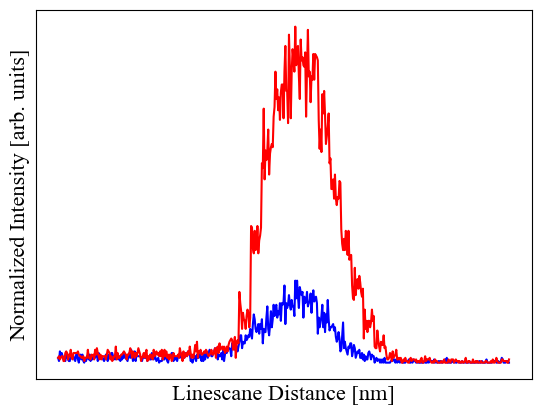

In [801]:
folder = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\SiC_TGS_Paper\\S3_CVD_SiC\\"

df1 = pd.read_excel(
    folder + "less_tungsten.xlsx",              # <- your file
    sheet_name=0,
    usecols=[1, 7],           # first two columns
    names=["Distance", "W_intensity"],  # set clean names
    header=0                  # or None if no header row
)

df2 = pd.read_excel(
    folder + "more_tungsten.xlsx",              # <- your file
    sheet_name=0,
    usecols=[1, 5],           # first two columns
    names=["Distance", "W_intensity"],  # set clean names
    header=0                  # or None if no header row
)
distance_less = df1['Distance'].to_numpy()
W_intensity_less = df1['W_intensity'].to_numpy()
distance_more = df2['Distance'].to_numpy()
W_intensity_more = df2['W_intensity'].to_numpy()

distance_less_index = np.where((distance_less[14:] >= 285) & (distance_less[14:] <= 385))[0]
distance_more_index = np.where((distance_more[14:] >= 400) & (distance_more[14:] <= 500))[0]


plt.plot(distance_less[distance_less_index] - np.min(distance_less[distance_less_index]), W_intensity_less[distance_less_index], color='b')
#plt.xlim([300, 400])
#plt.show()

plt.plot(distance_more[distance_more_index] - np.min(distance_more[distance_more_index]), W_intensity_more[distance_more_index], color='r')
#plt.xlim([400, 500])
plt.xticks([])
plt.yticks([])
plt.xlabel('Linescane Distance [nm]', fontsize=16)
plt.ylabel('Normalized Intensity [arb. units]', fontsize=16)
plt.show()


In the section below, the effect of contact thermal resistance on the temperature delta between the TZM plate and SiC surface is plotted based on results from an ansys simulation

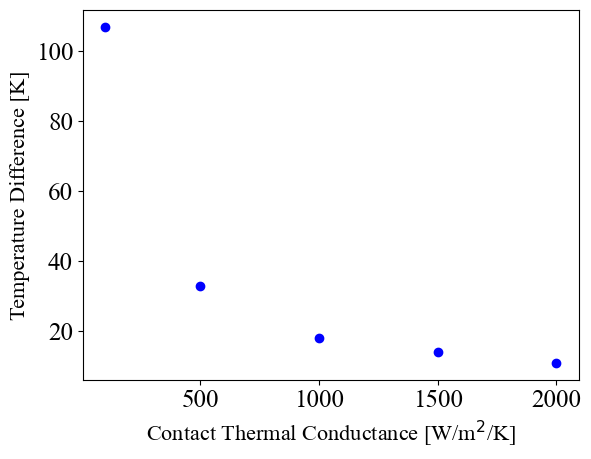

In [812]:
contact_conductance = np.array([100, 500, 1000, 1500, 2000]) # W/m^2/K
temp_max_SiC_Wcoat_1e5 = np.array([973, 968, 967, 966, 966]) # in C at heat flux of 1e5 W/m^2
temp_max_TZM_1e5 = np.array([695, 857, 897, 913, 922]) # in C at heat flux of 1e5 W/m^2
temp_max_SiC_Wcoat_25e3 = np.array([606, 604, 603, 603, 603]) # in C at heat flux of 25e3 W/m^2
temp_max_TZM_25e3 = np.array([499, 571, 585, 589, 592]) # in C at heat flux of 25e3 W/m^2

percent_diff_25e3 = 100*(temp_max_SiC_Wcoat_25e3 - temp_max_TZM_25e3)/temp_max_SiC_Wcoat_1e5
plt.scatter(contact_conductance, temp_max_SiC_Wcoat_25e3 - temp_max_TZM_25e3, color='b')
plt.xlabel(r'Contact Thermal Conductance [W/m$^2$/K]', fontsize=16)
plt.ylabel(r'Temperature Difference [K]', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=18, labelfontfamily='Times New Roman') 



In the script below, we read in the text files for gray scale vs distance and calculate the thickness of the tungsten layer

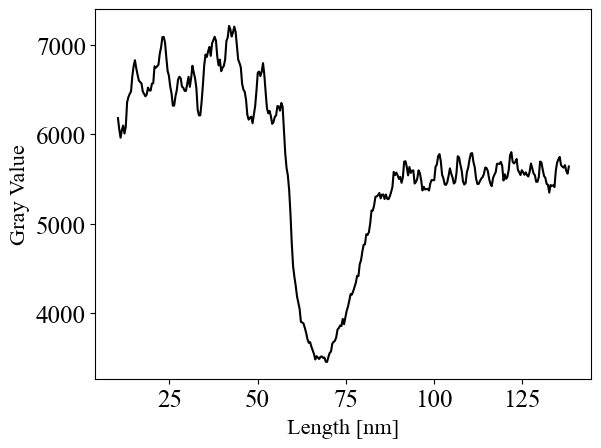

19.16855 0.9813814184607326


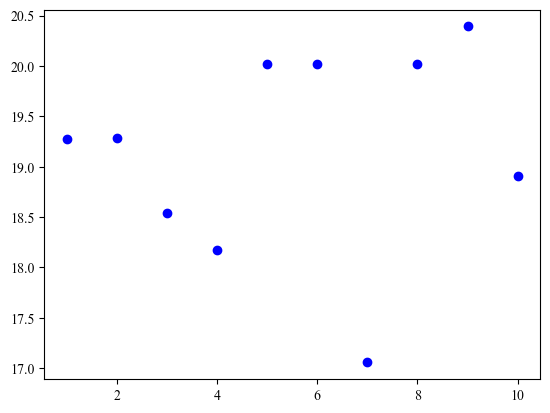

In [835]:
folder = "C:\\Users\\keshav98\\MIT Dropbox\\Keshav Vasudeva\\Research\\LSVV - SiCSiC Research\\Ion Irradiation\\Diffusivity_Experiment\\SiC_TGS_Paper\\S3_CVD_SiC\\"

# Looking at the data, it is clear that the left hand side of the tungsten will have a higher gray scale value, that has been hardcoded
thickness = []
for i in range(10):
    file = "line_" + str(i+1) + ".txt"
    data = np.loadtxt(folder+file, dtype=float, skiprows=29)
    x = np.array(data[:, 0])
    gray_scale = np.array(data[:, 1])
    if i == 1:
        plt.plot(x, gray_scale, 'k')
        plt.xlabel('Length [nm]', fontsize=16)
        plt.ylabel('Gray Value', fontsize=16)
        plt.tick_params(axis='both', which='major', labelsize=18, labelfontfamily='Times New Roman')
    gray_min = np.min(gray_scale)
    gray_min_index = np.where(gray_scale == gray_min)[0][0]
    gray_scale_max_1_index_range = int(0.2*len(x))
    gray_max_1 = np.mean(gray_scale[:gray_scale_max_1_index_range])
    #gray_max_1_index = np.where(gray_scale == gray_max_1)[0][0]
    gray_scale_max_2_index_range = int(0.8*len(x))
    gray_max_2 = np.mean(gray_scale[gray_scale_max_2_index_range:])
    gray_scale_mean_1 = (gray_max_1 + gray_min)*0.5
    gray_scale_mean_2 = (gray_max_2 + gray_min)*0.5
    #print(gray_scale_mean_1, gray_scale_mean_2)
    gray_scale_mean_1_index = np.where(gray_scale[:gray_min_index] <= gray_scale_mean_1)[0][0]
    gray_scale_mean_2_index = np.where(gray_scale[gray_min_index:] >= gray_scale_mean_2)[0][0] + gray_min_index
    thickness.append(x[gray_scale_mean_2_index] - x[gray_scale_mean_1_index])
    #print(gray_scale[gray_min_index:])
    
plt.show()
print(np.mean(thickness), np.std(thickness))

plt.scatter(np.array(range(10)) + 1, thickness, color='b')


